NumPy: 2.3.0
PySCIPOpt: 5.5.0
Experiment 1
Experiment 1: Vergleich von l0 ganzzahlig & kontinuierlich mit l1 ganzzahlig & kontinuierlich am Beispiel Kreis
Anzahl richtiger Lösungen bei Noise 0.0:
 - Ohne Presolve (Integer): 50
 - Ohne Presolve (Continuous): 50
 - l1-Variante (Integer): 50
 - l1-Variante (Continuous): 50
Durchschnittliches finales Epsilon bei richtiger Lösung:
 - Ohne Presolve (Integer): 0.0
 - Ohne Presolve (Continuous): 0.0
 - l1-Variante (Integer): 0.0
 - l1-Variante (Continuous): 0.0
Durchschnittliche Zeit bis zur richtigen Lösung:
 - Ohne Presolve (Integer): 0.01488366600475274 Sekunden
 - Ohne Presolve (Continuous): 0.01276220600004308 Sekunden
 - l1-Variante (Integer): 0.018173841999378056 Sekunden
 - l1-Variante (Continuous): 0.01460150200407952 Sekunden
Anzahl richtiger Lösungen bei Noise 0.001:
 - Ohne Presolve (Integer): 50
 - Ohne Presolve (Continuous): 49
 - l1-Variante (Integer): 50
 - l1-Variante (Continuous): 12
Durchschnittliches finales Epsilon bei ric

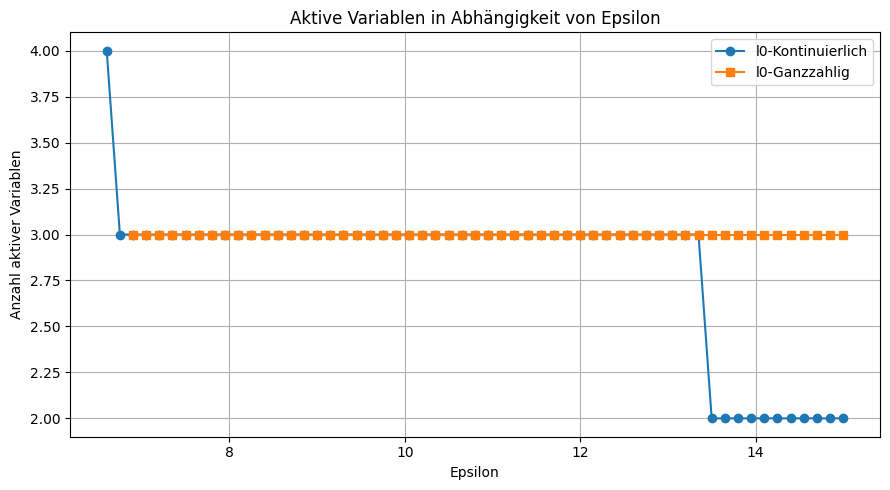

Experiment 5
Experiment 5: Vergleich von unterbestimmten Problemen am Beispiel der Lemniskate von Gerono
Start von l0-Integer für Pivot 4
Das Zeitlimit wurde überschritten. Breche diese Iteration ab.
Start von l0-Integer für Pivot 8
Das Zeitlimit wurde überschritten. Breche diese Iteration ab.
Start von l0-Integer für Pivot 3
Das Zeitlimit wurde überschritten. Breche diese Iteration ab.
Start von l0-Integer für Pivot 11
Das Zeitlimit wurde überschritten. Breche diese Iteration ab.
Start von l0-Integer für Pivot 7
Das Zeitlimit wurde überschritten. Breche diese Iteration ab.
Start von l0-Integer für Pivot 2
Start von l0-Continuous für Pivot 4
Start von l0-Continuous für Pivot 8
Start von l0-Continuous für Pivot 3
Start von l0-Continuous für Pivot 11
Start von l0-Continuous für Pivot 7
Start von l0-Continuous für Pivot 2
Start von l0-Continuous für Pivot 13
Start von l0-Continuous für Pivot 10
Start von l0-Continuous für Pivot 9
Start von l0-Continuous für Pivot 5
Start von l0-Continuous

In [ ]:
import numpy as np
from pyscipopt import Model, quicksum
import matplotlib.pyplot as plt
import time
import importlib.metadata
import pandas as pd
import math

def generate_data_gerono_random(n_points=20, noise=0.001):
    """
    Erzeugt Punkte auf oder nahe der Lemniskate von Gerono mit zufälligen Parametern t.
    """
    
    t = np.random.uniform(0, 2*np.pi, n_points)
    x = np.cos(t) + noise * np.random.randn(n_points)
    y = np.sin(t) * np.cos(t) + noise * np.random.randn(n_points)
    rhs=np.zeros(n_points)
    return list(zip(x, y)), rhs

def generate_circle_with_output_noise(
    n_points=50,
    noise_std=0.001
):
    rng = np.random.default_rng()
    winkel = rng.uniform(0.0, 2.0 * np.pi, n_points)
    x = np.cos(winkel)
    y = np.sin(winkel)
    data = list(zip(x, y))
    rhs = noise_std * rng.standard_normal(n_points)

    return data, rhs

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_data_line_circle(noise=0.0):
    """
    Datengenerierung für Schnittpunkt zwischen Einheitskreis und Gerade 10y - 9x = 0
    """
    a = 0.9
    x0 = 1.0 / np.sqrt(1.0 + a**2)
    y0 = a * x0

    pts = [
        (x0, y0),
        (-x0, -y0)
    ]

    if noise > 0:
        pts = [
            (x + noise * np.random.randn(), y + noise * np.random.randn())
            for x, y in pts
        ]

    return pts

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def _build_coefficient_vector(monomial_powers, terms):
    """Erzeugt den Koeffizientenvektor für die gegebene Monomreihenfolge."""
    return np.array(
        [terms.get(power, 0.0) for power in monomial_powers],
        dtype=float,
    )


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def circle_true_coefficients(monomial_powers):
    """Koeffizienten von x² + y² - 1 in der verwendeten Monomreihenfolge."""
    terms = {
        (0, 0): -1.0,
        (2, 0): 1.0,
        (0, 2): 1.0,
    }
    return _build_coefficient_vector(monomial_powers, terms)


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def gerono_true_coefficients(monomial_powers):
    """Koeffizienten von x⁴ - x² + y² in der verwendeten Monomreihenfolge."""
    terms = {
        (4, 0): 1.0,
        (2, 0): -1.0,
        (0, 2): 1.0,
    }
    return _build_coefficient_vector(monomial_powers, terms)

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def check_polynomial_solution_scale_invariant(
    coeffs,
    true_coeffs,
    monomial_powers,
    polynomial_name="Polynom",
    target_expression=None,
    l2_tol=0.10,
    support_tol=1e-4,
    zero_tol=1e-12,
    verbose=True,
):
    """Vergleicht ein gefundenes Polynom skalierungsunabhängig mit der Referenz."""
    coeffs = np.asarray(coeffs, dtype=float)
    true_coeffs = np.asarray(true_coeffs, dtype=float)

    if coeffs.shape != true_coeffs.shape:
        raise ValueError("Die Koeffizientenvektoren müssen gleich lang sein.")
    

    def support(values):
        threshold = max(zero_tol, support_tol * np.max(np.abs(values)))
        return {
            power
            for power, value in zip(monomial_powers, values)
            if abs(value) > threshold
        }

    coeff_norm = np.linalg.norm(coeffs)
    true_norm = np.linalg.norm(true_coeffs)

    if true_norm <= zero_tol:
        raise ValueError("Das Zielpolynom darf nicht das Nullpolynom sein.")

    true_support = support(true_coeffs)

    if coeff_norm <= zero_tol:
        found_support = set()
        scaling_factor = float("nan")
        aligned_coeffs = np.zeros_like(coeffs)
        rel_l2_error = float("inf")
    else:
        found_support = support(coeffs)
        scaling_factor = float(
            np.dot(coeffs, true_coeffs) / np.dot(coeffs, coeffs)
        )
        aligned_coeffs = scaling_factor * coeffs
        rel_l2_error = float(
            np.linalg.norm(aligned_coeffs - true_coeffs) / true_norm
        )

    support_ok = found_support == true_support
    l2_ok = rel_l2_error <= l2_tol
    is_correct = support_ok and l2_ok

    if verbose:
        print(f"\n{polynomial_name}-Prüfung")
        print("-" * (len(polynomial_name) + 8))

        if target_expression is not None:
            print(f"Zielpolynom:             {target_expression}")

        print(f"Gefundener Support:      {sorted(found_support)}")
        print(f"Ziel-Support:            {sorted(true_support)}")
        print(f"Support korrekt:         {support_ok}")
        print(f"Skalierungsfaktor:       {scaling_factor:.8g}")
        print(f"Relative L2-Abweichung:  {rel_l2_error:.6e}")
        print(f"L2-Toleranz:             {l2_tol:.6e}")
        print(f"L2 korrekt:              {l2_ok}")
        print(f"Gesamt korrekt:          {is_correct}")

        if coeff_norm > zero_tol:
            print("Skalierte Koeffizienten:")
            print(aligned_coeffs)

    return is_correct, rel_l2_error, support_ok

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def check_circle_solution(
    coeffs,
    monomial_powers,
    l2_tol=0.10,
    support_tol=1e-4,
    zero_tol=1e-12,
    verbose=True,
):
    """Prüft die gefundene Gleichung gegen den Einheitskreis."""
    return check_polynomial_solution_scale_invariant(
        coeffs=coeffs,
        true_coeffs=circle_true_coefficients(monomial_powers),
        monomial_powers=monomial_powers,
        polynomial_name="Kreis",
        target_expression="x^2 + y^2 - 1 = 0",
        l2_tol=l2_tol,
        support_tol=support_tol,
        zero_tol=zero_tol,
        verbose=verbose,
    )

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def check_gerono_solution(
    coeffs,
    monomial_powers,
    l2_tol=0.05,
    support_tol=1e-4,
    zero_tol=1e-12,
    verbose=True,
):
    """Prüft die gefundene Gleichung gegen die Lemniskate von Gerono."""
    return check_polynomial_solution_scale_invariant(
        coeffs=coeffs,
        true_coeffs=gerono_true_coefficients(monomial_powers),
        monomial_powers=monomial_powers,
        polynomial_name="Gerono",
        target_expression="x^4 - x^2 + y^2 = 0",
        l2_tol=l2_tol,
        support_tol=support_tol,
        zero_tol=zero_tol,
        verbose=verbose,
    )



def presolve_bounds(phi_matrix, y, eps_tol=1e-3, B=10.0):
    """
    Bounds-Tightening wie in der Masterarbeit beschrieben.
    """
    n_samples = len(phi_matrix)
    n_monomials = len(phi_matrix[0])
    bounds = []
    for j in range(n_monomials):
        lb, ub = None, None
        for sense in ["minimize", "maximize"]:
            lp = Model("bound")
            c = [lp.addVar(lb=-B, ub=B) for _ in range(n_monomials)]
            eps = [lp.addVar(lb=0.0) for _ in range(n_samples)]
            for i in range(n_samples):
                expr = quicksum(phi_matrix[i][k] * c[k] for k in range(n_monomials))
                if y is not None:
                    lp.addCons(expr - y[i] <= eps[i])
                    lp.addCons(y[i] - expr <= eps[i])
                else:
                    lp.addCons(expr <= eps[i])
                    lp.addCons(expr >= -eps[i])
            lp.addCons(quicksum(eps) <= eps_tol)

            expr = quicksum(c[k] for k in range(n_monomials))
            lp.addCons(expr <= 1)
            lp.addCons(expr >= 1)
            lp.setObjective(c[j], sense)
            lp.hideOutput()
            lp.optimize()
            val = lp.getObjVal()

            if sense == "minimize":
                lb = val
            else:
                ub = val

        bounds.append((lb, ub))

    return bounds



def build_sparse_polynomial_mip(phi_matrix,
                                bounds,
                                eps_tol,
                                type_eps="full",
                                pivot_idx=None,
                                fixed_zero_indices=None,
                                rhs=None,
                                type_variables="integer",
                                big_m=10.0,
                                sparsity_by_pivot_l1_presolve=None):
    """
    Baut und liefert das MILP-Modell inkl. Variablen zurück.
    """
    n_samples = len(phi_matrix)
    n_monomials = len(phi_matrix[0])
    model = Model("Sparse Polynomial Fitting")
    if rhs is None:
        rhs = np.zeros(n_samples)
    if type_eps not in {"point", "full", "objective"}:
        raise ValueError("Ungültiger Typ für Residuen: " + type_eps)
    w = []
    z = []
    for j in range(n_monomials):
        lb, ub = bounds[j]
        lb = -big_m if lb is None else lb
        ub = big_m if ub is None else ub
        if type_variables == "integer":
            wj = model.addVar(name=f"w_{j}", lb=lb, ub=ub, vtype="I")
        elif type_variables == "continuous":
            wj = model.addVar(name=f"w_{j}", lb=lb, ub=ub, vtype="C")
        else:
            raise ValueError("Ungültiger Typ für Variablen: " + type_variables)
        if type_eps!="objective":
            zj = model.addVar(name=f"z_{j}", vtype="B")

        w.append(wj)
        if type_eps!="objective":
            z.append(zj)
    
    support_bound = None
    if sparsity_by_pivot_l1_presolve is not None:
        support_bound = sparsity_by_pivot_l1_presolve.get(pivot_idx)
    if support_bound is not None and type_eps != "objective":
        model.addCons(quicksum(z) <= support_bound)
    
    eps = [model.addVar(name=f"eps_{i}", lb=0.0)
           for i in range(n_samples)]
    if type_eps!="objective":
        for j in range(n_monomials):
            lb, ub = bounds[j]
            lb = -big_m if lb is None else lb
            ub = big_m if ub is None else ub
            model.addCons(w[j] <= ub * z[j])
            model.addCons(w[j] >= lb * z[j])

    if fixed_zero_indices is not None:
        for j in fixed_zero_indices:
            model.addCons(w[j] == 0.0)
            if type_eps!="objective":
                model.addCons(z[j] == 0)
    if pivot_idx is not None:
        model.addCons(w[pivot_idx] == 1.0)
        if type_eps!="objective":
            model.addCons(z[pivot_idx] == 1)
    if pivot_idx is None:
        model.addCons(quicksum(w) == 1)

    for i in range(n_samples):
        expr = quicksum(phi_matrix[i][j] * w[j]
                        for j in range(n_monomials))
        model.addCons(expr - rhs[i] <= eps[i])
        model.addCons(rhs[i] - expr <= eps[i])
       
        if type_eps=="point":
            model.addCons(eps[i] <= eps_tol)
    if type_eps == "full":
        model.addCons(quicksum(eps) <= eps_tol)
    if type_eps=="objective":
        model.setObjective(
            quicksum(eps),
            "minimize"
        )
    else:
        model.setObjective(
            quicksum(z),
            "minimize"
        )

    return model, w, z, eps

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def presolve_check_support_bound(Phi, y, eps_tol, bounds, tol=1e-8):
    Phi = np.asarray(Phi, dtype=float)
    y = np.asarray(y, dtype=float)

    best_error = np.inf
    best_index = None
    best_coeff = None

    for j in range(Phi.shape[1]):
        column = Phi[:, j]
        lb, ub = bounds[j]

        indices = np.abs(column) > 1e-12

        if not np.any(indices):
            coeff = 0.0
        else:
            values = y[indices] / column[indices]
            weights = np.abs(column[indices])

            order = np.argsort(values)
            values = values[order]
            weights = weights[order]

            cumulative_weights = np.cumsum(weights)

            median_index = np.searchsorted(
                cumulative_weights,
                np.sum(weights) / 2,
                side="left"
            )

            coeff = values[median_index]
            coeff = np.clip(coeff, lb, ub)

        error = np.sum(np.abs(column * coeff - y))

        if error < best_error:
            best_error = error
            best_index = j
            best_coeff = coeff

    if best_error <= eps_tol + tol:
        return 1, best_index, best_coeff, best_error

    return 2, None, None, best_error


def build_sparse_explicit_regression_mip(
    Phi,
    y,
    feature_library,
    bounds,
    eps_tol=1e-8,
    type_variables="integer",
    support_bound=1
):
    """
    Sparse Regression für symbolischer Regression mit nichtverschwindender rechter Seite y wie in der Masterarbeit beschrieben. 
    """
    n_samples, n_features = Phi.shape

    model = Model("Sparse Explicit Regression")
    model.hideOutput()
    c = []
    z = []
    u = []
    for j in range(n_features):
        lb,ub=bounds[j]
        if type_variables=="integer":
            cj = model.addVar(name=f"c_{j}", lb=lb, ub=ub, vtype="I")
        elif type_variables=="continuous":
            cj = model.addVar(name=f"c_{j}", lb=lb, ub=ub, vtype="C")
        else:
            raise ValueError(f"Unbekannter Parameter für type_variables: {type_variables}")
        zj = model.addVar(name=f"z_{j}", vtype="B")
        model.addCons(cj <= ub * zj)
        model.addCons(cj >= lb * zj)

        c.append(cj)
        z.append(zj)
    eps = [model.addVar(name=f"eps_{i}", lb=0.0) for i in range(n_samples)]

    for i in range(n_samples):
        pred_i = quicksum(Phi[i, j] * c[j] for j in range(n_features))
        model.addCons(pred_i - y[i] <= eps[i])
        model.addCons(y[i] - pred_i <= eps[i])

    model.addCons(quicksum(eps) <= eps_tol)
    if support_bound is not None:
        if support_bound == 1:
            model.addCons(quicksum(z) == 1)
        else:
            model.addCons(quicksum(z)>=2)
    obj = (
        quicksum(z[j] for j in range(n_features))
    )

    model.setObjective(obj, "minimize")
    return model, c, z, u, eps


def sequential_sparse_fit_nogood(phi_matrix,
                                bounds,
                                eps_tol,
                                big_m,
                                V_kernel,
                                rhs=None,
                                pivot_tau=1e-3,
                                example_type="so3",
                                max_degree=2,
                                verbose=True):
    """
    Implementierung des No-Good-Cut-Verfahrens wie in der Masterarbeit beschrieben.
    """
    times=[]
    maximum_equations = 0
    if V_kernel is None or V_kernel.shape[1] == 0:
        if verbose:
            print("Kein (numerischer) Kern vorhanden -> No-good Verfahren liefert nichts.")
        return [], [], []
    pivot_candidates = choose_basis_invariant_pivots(V_kernel, tol=pivot_tau)
    if len(pivot_candidates) == 0:
        if verbose:
            print("Keine Pivotkandidaten mit rho_j > pivot_tau vorhanden.")
        return [], [], []

    solutions = []
    seen_supports = []
    if verbose:
        print(f"\nNo-good Cut Verfahren: max {maximum_equations} Gleichungen (Kern-Dim t={V_kernel.shape[1]})")
        print("Pivot-Kandidaten (erste 15):", pivot_candidates[:15])
    if example_type == "so3":
        if max_degree == 2:
            maximum_equations=20
        elif max_degree == 3:
            maximum_equations=136
        elif max_degree == 4:
            maximum_equations=550
    elif example_type == "rank1_2x3":
        maximum_equations=3
    rank_W = 0
    l=0
    start_time = time.perf_counter()
    while rank_W < maximum_equations:
        l+=1
        if l > 200:            
            if verbose:
                print(f"Abbruch nach {l} Iterationen (maximum_equations={maximum_equations}, rank_W={rank_W})")
                break
        found = False
        for p in pivot_candidates:
            model, w, z, eps = build_sparse_polynomial_mip(
                phi_matrix=phi_matrix,
                bounds=bounds,
                eps_tol=eps_tol,
                big_m=big_m,
                pivot_idx=p,
                fixed_zero_indices=None,
                rhs=rhs
            )
            for z_prev in seen_supports:
                S1 = [j for j, val in enumerate(z_prev) if val > 0.5]
                S0 = [j for j, val in enumerate(z_prev) if val <= 0.5]

                model.addCons(
                    quicksum(1 - z[j] for j in S1) +
                    quicksum(z[j] for j in S0) >= 1
                )
            model.hideOutput()
            model.optimize()
            status = model.getStatus()
            if status == "optimal":
                w_vals = np.array([model.getVal(wj) for wj in w], dtype=float)
                z_vals = np.array([model.getVal(zj) for zj in z], dtype=float)
                if abs(w_vals[p] - 1.0) > 1e-5:
                    continue

                existing_ws = [sol[0] for sol in solutions]
                if is_duplicate(w_vals, existing_ws):
                    continue
                solutions.append((w_vals, z_vals, p))
                W = np.array([w_vals for (w_vals, z_vals, p) in solutions], dtype=float)

                rank_W = np.linalg.matrix_rank(W, tol=1e-9)
                seen_supports.append(z_vals.copy())
                found = True
                if verbose:
                    nnz = int(np.sum(z_vals > 0.5))
                    print(f"Iteration {l+1}: Pivot {p} -> Lösung gefunden, #active={nnz}")
                    end_time = time.perf_counter()
                    times.append(end_time - start_time)
                    start_time = time.perf_counter()

                break
            else:
                print(f"Pivot-Kandidat {p} -> Keine zulässige Gleichung gefunden")
                pivot_candidates.remove(p)
                continue
        if not found:
            if verbose:
                print(f"Iteration {l+1}: keine neue zulässige Gleichung gefunden -> Stop.")
            break
    print(f"Ende: {len(solutions)} Gleichungen gefunden, rank(W)={rank_W}, Anzahl Iterationen:{l}")

    return solutions, seen_supports, times

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def is_duplicate(w_new, existing_ws, tol=1e-3):
    w_new_n = normalize_polynomial(w_new)

    for w_old in existing_ws:
        w_old_n = normalize_polynomial(w_old)

        if np.linalg.norm(w_new_n - w_old_n) < tol:
            return True

    return False

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def normalize_polynomial(w, tol=1e-8):
    w = np.array(w, dtype=float)

    if np.linalg.norm(w) < tol:
        return w

    w = w / np.linalg.norm(w)

    for i in range(len(w)):
        if abs(w[i]) > tol:
            if w[i] < 0:
                w = -w
            break

    return w


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def choose_basis_invariant_pivots(
    V_kernel,
    tol=1e-10
):
    """
    Sortierung der Pivotkandidaten wie in der Masterarbeit beschrieben
    """
    N = orthonormalize_kernel_basis(
        V_kernel,
        tol=tol
    )

    if N.shape[1] == 0:
        return []

    scores = np.linalg.norm(N, axis=1)

    order = np.lexsort((
        np.arange(scores.size),
        -scores
    ))

    return [
        int(j)
        for j in order
        if scores[j] > tol
    ]


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def orthonormalize_kernel_basis(V_kernel, tol=1e-12):
    """
    Erzeugt eine Orthonormalbasis des von den Spalten von
    V_kernel aufgespannten Unterraums.
    """
    V_kernel = np.asarray(V_kernel, dtype=float)

    if V_kernel.ndim != 2 or V_kernel.shape[1] == 0:
        return np.empty((V_kernel.shape[0], 0))

    U, singular_values, _ = np.linalg.svd(
        V_kernel,
        full_matrices=False
    )

    if singular_values.size == 0:
        return np.empty((V_kernel.shape[0], 0))

    rank = np.sum(
        singular_values > tol * singular_values[0]
    )

    return U[:, :rank]




def build_l1_polynomial_model(phi_matrix,
                           bounds,
                           eps_tol,
                           type_eps="full",
                           type_variables="integer",
                           rhs=None,
                           pivot_idx=None):
    """
    Baut das LP mit l₁-Regularisierung.
    """
    n_samples = len(phi_matrix)
    n_monomials = len(phi_matrix[0])
    model = Model("L1 Polynom Fitting")
    if rhs is None:
        rhs = np.zeros(n_samples)
    c = []
    u = []
    for j in range(n_monomials):
        lb, ub = bounds[j]
        if type_variables == "integer":
            cj = model.addVar(name=f"c_{j}", lb=lb, ub=ub, vtype="I")
        else:
            cj = model.addVar(name=f"c_{j}", lb=lb, ub=ub, vtype="C")
        uj = model.addVar(name=f"u_{j}", lb=0.0)
        model.addCons(cj <= uj)
        model.addCons(-cj <= uj)
        c.append(cj)
        u.append(uj)
    eps = [model.addVar(name=f"eps_{i}", lb=0.0)
        for i in range(n_samples)]
    for i in range(n_samples):
        expr = quicksum(phi_matrix[i][j] * c[j]
                        for j in range(n_monomials))
        model.addCons(expr - rhs[i] <= eps[i])
        model.addCons(rhs[i] - expr <= eps[i])
        if type_eps=="point":
            model.addCons(eps[i] <= eps_tol)
    if pivot_idx is not None:
        model.addCons(c[pivot_idx] == 1.0)
    if type_eps == "full":
        model.addCons(quicksum(eps) <= eps_tol)
    model.addCons(quicksum(c) == 1)

    model.setObjective(
        quicksum(u),
        "minimize"
    )
    return model, c, u, eps

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def reduce_phi_by_kernel(Phi, tau_rel=1e-6, coeff_tol=1e-2, verbose=True):
    """
    Kernbasierte Monomselektion wie in der Masterarbeit beschrieben
    """
    Phi = np.asarray(Phi, dtype=float)

    V_kernel_full, singular_values, rank, svd_tol = numerical_kernel_basis(
        Phi,
        tau_rel=tau_rel
    )
    kernel_dim = V_kernel_full.shape[1]

    if kernel_dim == 0:
        return Phi, list(range(Phi.shape[1])), [], None

    rho = np.linalg.norm(V_kernel_full, axis=1)
    used = rho > coeff_tol

    kept_indices = np.flatnonzero(used).tolist()
    removed_indices = np.flatnonzero(~used).tolist()

    if len(kept_indices) == 0:
        raise ValueError(
            "Die kernbasierte Monomselektion hat alle Monome entfernt. "
            "Verringere coeff_tol oder überprüfe tau_rel."
        )

    Phi_reduced = Phi[:, kept_indices]

    V_kernel_reduced, _, reduced_rank, reduced_svd_tol = numerical_kernel_basis(
        Phi_reduced,
        tau_rel=tau_rel
    )

    if V_kernel_reduced.shape[1] == 0:
        V_kernel_reduced = None

    return (
        Phi_reduced,
        kept_indices,
        removed_indices,
        V_kernel_reduced
    )

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def numerical_kernel_basis(Phi, tau_rel=1e-6, tau_abs=0.0):
    """
    Berechnet eine Orthonormalbasis des numerischen Kerns von Phi.
    """
    Phi = np.asarray(Phi, dtype=float)

    if Phi.ndim != 2:
        raise ValueError("Phi muss eine zweidimensionale Matrix sein.")

    _, singular_values, Vt = np.linalg.svd(Phi, full_matrices=True)

    if singular_values.size == 0:
        tol = float(tau_abs)
        rank = 0
    else:
        tol = max(float(tau_abs), float(tau_rel) * singular_values[0])
        rank = int(np.sum(singular_values > tol))

    V_kernel = Vt[rank:, :].T

    return V_kernel, singular_values, rank, tol

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def gaussian_l1_noise_budget(
    n_points,
    noise_std,
    confidence=0.95,
    n_simulations=200_000
):
    """
    Schätzt die Fehlertoleranz epsilon mithilfe einer Monte-Carlo-Simulation.
    """
    if noise_std <= 0:
        return 0.0

    noise = np.random.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_simulations, n_points)
    )

    error_sums = np.sum(np.abs(noise), axis=1)
    epsilon = np.quantile(error_sums, confidence)

    return float(epsilon)


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def get_example_config(example_type="so3"):
    """
    Gibt die entsprechende Anzahl der Variablen mit Namen zurück für die Konfigurationen so3 und rank1_2x3 für das sequentielle Problem
    """
    if example_type == "so3":
        var_names = [
            "r11", "r12", "r13",
            "r21", "r22", "r23",
            "r31", "r32", "r33"
        ]
        pretty_matrix_shape = (3, 3)
        n_vars = 9
        return n_vars, var_names, pretty_matrix_shape

    elif example_type == "rank1_2x3":
        var_names = [
            "a11", "a12", "a13",
            "a21", "a22", "a23"
        ]
        pretty_matrix_shape = (2, 3)
        n_vars = 6
        return n_vars, var_names, pretty_matrix_shape


    else:
        raise ValueError("example_type muss 'so3', 'rank1_2x3'.")
    
# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_example_data(example_type="so3",
                          count_points=100,
                          noise=0.0):
    """
    Datengenerierung für das übergebene Beispiel so3 oder rank1_2x3
    """
    if example_type == "so3":
        return generate_data_so3(
            n_points=count_points,
            noise=noise,
            flatten=True
        )

    elif example_type == "rank1_2x3":
        return generate_data_rank1_2x3(
            n_points=count_points,
            noise=noise,
            flatten=True
        )


    else:
        raise ValueError("example_type muss 'so3', 'rank1_2x3' sein.")

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt  
def generate_data_so3(n_points=20, noise=0.0, flatten=True):
    """
    Daten-Generierung auf SO(3)
    """
    data = []

    for _ in range(n_points):
        R = sample_random_rotation()

        if noise > 0:
            R = R + noise * np.random.randn(3, 3)

        data.append(R.reshape(-1) if flatten else R)

    return data

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def sample_random_rotation():
    q = np.random.randn(4)
    q = q / np.linalg.norm(q)
    return quaternion_to_rotation_matrix(q)

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def quaternion_to_rotation_matrix(q):
    """
    q: Quaternion [w, x, y, z], normiert
    Rückgabe: 3x3-Rotationsmatrix
    """
    w, x, y, z = q

    R = np.array([
        [1 - 2*(y**2 + z**2),   2*(x*y - z*w),       2*(x*z + y*w)],
        [2*(x*y + z*w),         1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),         2*(y*z + x*w),       1 - 2*(x**2 + y**2)]
    ])
    return R

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_data_rank1_2x3(n_points=20, noise=0.0, flatten=True):
    data = []

    for _ in range(n_points):
        M = sample_rank1_matrix_2x3()

        if noise > 0:
            M = M + noise * np.random.randn(2, 3)

        data.append(M.reshape(-1) if flatten else M)

    return data

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def sample_rank1_matrix_2x3(scale_u=1.0, scale_v=1.0):
    u = scale_u * np.random.randn(2)
    v = scale_v * np.random.randn(3)
    M = np.outer(u, v)
    return M

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_monomials_nvars(n_vars, max_degree):
    monomials = []

    def rec_build(prefix, remaining_vars, remaining_degree):
        if remaining_vars == 1:
            for d in range(remaining_degree + 1):
                monomials.append(tuple(prefix + [d]))
            return

        for d in range(remaining_degree + 1):
            rec_build(prefix + [d], remaining_vars - 1, remaining_degree - d)

    rec_build([], n_vars, max_degree)
    return monomials

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_monomials_sr(max_degree, n_variables):
    """
    Alle Exponenten-Tupel (a1,...,ad) mit Gesamtgrad <= max_degree.
    """
    powers = []

    def rec_build(prefix, remaining_degree, remaining_vars):
        if remaining_vars == 1:
            for k in range(remaining_degree + 1):
                powers.append(tuple(prefix + [k]))
            return

        for k in range(remaining_degree + 1):
            rec_build(prefix + [k], remaining_degree - k, remaining_vars - 1)

    rec_build([], max_degree, n_variables)
    return powers

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def build_phi_matrix(data, monomial_powers):
    phi_matrix = []
    for point in data:
        row = [evaluate_monomial(point, powers) for powers in monomial_powers]
        phi_matrix.append(row)
    return phi_matrix
# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def evaluate_monomial(point, powers):
    val = 1.0
    for x, p in zip(point, powers):
        if p != 0:
            val *= x ** p
    return val

def sequential_sparse_pivot_fit(phi_matrix,
                          bounds,
                          eps_tol,
                          big_m,
                          V_kernel,
                          rhs=None,
                          pivot_tau=1e-3,
                          max_equations=None,
                          verbose=True,
                          use_pivot_presolve_bounds=False):
    """
    Implementierung der Pivot-Methode
    """

    if V_kernel is None or V_kernel.shape[1] == 0:
        if verbose:
            print("Kein (numerischer) Kern vorhanden -> sequentielles Verfahren liefert nichts.")
        return [], [], []
    pivot_candidates = choose_basis_invariant_pivots(V_kernel, tol=pivot_tau)
    if len(pivot_candidates) == 0:
        if verbose:
            print("Keine Pivotkandidaten mit rho_j > pivot_tau vorhanden.")
        return [], [], []

    used_pivots = []
    solutions = []
    times=[]
    no_solution_pivots = []

    t = V_kernel.shape[1]
    limit = t if max_equations is None else min(max_equations, t)
    if verbose:
        print(f"\nSequentielles Lösen: max {limit} Gleichungen (Kern-Dim t={t})")
        print("Pivot-Kandidaten (erste 15):", pivot_candidates[:15])
    start_time=time.perf_counter()
    for l in range(limit):
        found = False
        for p in pivot_candidates:
            if p in used_pivots or p in no_solution_pivots:
                continue
            fixed_zero = used_pivots[:]
            if use_pivot_presolve_bounds:
                pivot_bounds = presolve_bounds_for_pivot(
                    phi_matrix=phi_matrix,
                    pivot_idx=p,
                    eps_tol=eps_tol,
                    B=big_m,
                    verbose=False
                )
                valid_bounds = []
                for j, (lb, ub) in enumerate(pivot_bounds):
                    if lb is None or ub is None:
                        valid_bounds.append((-big_m, big_m))
                    else:
                        valid_bounds.append((lb, ub))
            else:
                valid_bounds = bounds
            model, w, z, eps = build_sparse_polynomial_mip(
                phi_matrix=phi_matrix,
                bounds=valid_bounds,
                eps_tol=eps_tol,
                big_m=big_m,
                pivot_idx=p,
                fixed_zero_indices=fixed_zero,
                rhs=rhs
            )
            model.hideOutput()
            model.optimize()

            status = model.getStatus()
            if status != "optimal":
                print(f"Iteration {l+1}: Pivot {p} -> Keine Lösung gefunden")
                no_solution_pivots.append(p)
                continue
            w_vals = np.array([model.getVal(wj) for wj in w], dtype=float)
            z_vals = np.array([model.getVal(zj) for zj in z], dtype=float)
            if abs(w_vals[p] - 1.0) > 1e-5:
                continue
            used_pivots.append(p)
            solutions.append((w_vals, z_vals, p))
            found = True
            if verbose:
                nnz = int(np.sum(z_vals > 0.5))
                end_time = time.perf_counter()
                print(f"Iteration {l+1}: Pivot {p} -> Lösung gefunden, #active={nnz}")
                times.append(end_time - start_time)
                start_time = time.perf_counter()
            break
        if not found:
            if verbose:
                print(f"Iteration {l+1}: keine neue zulässige Gleichung gefunden -> Stop.")
            break

    return solutions, used_pivots, times

def presolve_bounds_for_pivot(phi_matrix, pivot_idx, eps_tol=1e-3, B=10.0, verbose=False):
    """
    Verallgemeinert die Bounds Berechnung auf Pivots für das sequentielle Problem. Wird allerdings in den Experimenten nicht genutzt. 
    """
    n_samples = len(phi_matrix)
    n_monomials = len(phi_matrix[0])
    bounds = []

    for j in range(n_monomials):
        lb, ub = None, None
        for sense in ["minimize", "maximize"]:
            lp = Model(f"bound_pivot_{pivot_idx}_{j}_{sense}")
            c = [lp.addVar(lb=-B, ub=B, vtype="C", name=f"c_{k}") for k in range(n_monomials)]
            eps = [lp.addVar(lb=0.0, vtype="C", name=f"eps_{i}") for i in range(n_samples)]
            for i in range(n_samples):
                expr = quicksum(phi_matrix[i][k] * c[k] for k in range(n_monomials))
                lp.addCons(expr <= eps[i])
                lp.addCons(expr >= -eps[i])

            lp.addCons(quicksum(eps[i] for i in range(n_samples)) <= eps_tol)
            lp.addCons(c[pivot_idx] == 1.0)

            lp.setObjective(c[j], sense)
            lp.hideOutput()
            lp.optimize()
            status = lp.getStatus()
            if status != "optimal":
                if verbose:
                    print(f"Presolve infeasible/kein optimum für Pivot {pivot_idx}, Koeff {j}, sense={sense}, status={status}")
                lb, ub = None, None
                break

            val = lp.getObjVal()
            if sense == "minimize":
                lb = val
            else:
                ub = val
        bounds.append((lb, ub))

    print("Bounds: ", bounds)
    return bounds

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_exact_so3_validation_data(
    n_points=100,
    seed=12345,
    flatten=True
):
    """
    Erzeugt einen reproduzierbaren, unabhängigen Testdatensatz
    aus rauschfreien SO(3)-Matrizen.
    """

    rng = np.random.default_rng(seed)
    data = []

    for _ in range(n_points):
        q = rng.standard_normal(4)
        q_norm = np.linalg.norm(q)

        q = q / q_norm

        R = quaternion_to_rotation_matrix(q)
        data.append(R.reshape(-1) if flatten else R)

    return data

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def so3_validation_data_diagnostics(data):
    """
    Prüft, wie genau die Validierungsdaten selbst auf SO(3) liegen.
    """
    rotations = np.asarray(data, dtype=float).reshape(-1, 3, 3)

    orthogonality_errors = np.array([
        np.linalg.norm(R.T @ R - np.eye(3), ord="fro")
        for R in rotations
    ])

    determinant_errors = np.array([
        abs(np.linalg.det(R) - 1.0)
        for R in rotations
    ])

    return {
        "n_points": len(rotations),
        "max_orthogonality_error": float(
            np.max(orthogonality_errors)
        ),
        "mean_orthogonality_error": float(
            np.mean(orthogonality_errors)
        ),
        "max_determinant_error": float(
            np.max(determinant_errors)
        ),
        "mean_determinant_error": float(
            np.mean(determinant_errors)
        ),
    }

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def validate_polynomial_solutions(
    solutions,
    monomial_powers,
    validation_data,
    atol=1e-8
):
    passed = []
    failed = []

    for idx, (w_vals, _, _) in enumerate(solutions, start=1):
        values = evaluate_polynomial_nvars(
            w_vals,
            monomial_powers,
            validation_data
        )

        if np.all(np.abs(values) <= atol):
            passed.append(idx)
        else:
            failed.append(idx)

    return passed, failed

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def evaluate_polynomial_nvars(w_vals, monomial_powers, data):
    results = []
    for point in data:
        val = 0.0
        for coeff, powers in zip(w_vals, monomial_powers):
            val += coeff * evaluate_monomial(point, powers)
        results.append(val)
    return results

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def print_validation_summary(result, title):
    passed, failed = result

    passed_text = ", ".join(map(str, passed)) if passed else "keine"
    failed_text = ", ".join(map(str, failed)) if failed else "keine"

    print(f"\n{title}")
    print(f"Bestandene Gleichungen: {passed_text}")
    print(f"Nicht bestandene Gleichungen: {failed_text}")


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def print_method_comparison(solutions_fixed, solutions_nogood, time_fixed, time_nogood,monomial_powers,data):
    print(f"VERGLEICH DER VERFAHREN")

    header = f"{'Methode':<18} | {'#Gleichungen':>12} | {'Zeit [s]':>10}"
    print(header)
    print("-" * len(header))
    print(f"{'Pivot':<18} | {len(solutions_fixed):>12} |  {time_fixed:>10.4f}")
    print(f"{'No-good cuts':<18} | {len(solutions_nogood):>12} | {time_nogood:>10.4f}")

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def print_polynomial_block(label, w_vals, monomial_powers, var_names, z_vals=None, coeff_tol=0.5):
    print(label)
    terms = format_polynomial_terms(w_vals, monomial_powers, z_vals=z_vals, var_names=var_names, coeff_tol=coeff_tol)
    if not terms:
        print("(keine aktiven Terme)")
        return
    for coeff, mon in terms:
        print(f"{coeff:+.6f} * {mon}")
# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def format_polynomial_terms(w_vals, monomial_powers, z_vals=None, var_names=None, coeff_tol=0.5):
    terms = []
    for idx, (coeff, powers) in enumerate(zip(w_vals, monomial_powers)):
        if z_vals is not None and z_vals[idx] <= 0.5:
            continue
        if abs(coeff) <= coeff_tol:
            continue
        mon = format_monomial(powers, var_names)
        terms.append((coeff, mon))
    return terms
# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def format_monomial(powers, var_names=None):
    if var_names is None:
        var_names = [f"x{i+1}" for i in range(len(powers))]

    terms = []
    for name, p in zip(var_names, powers):
        if p == 0:
            continue
        elif p == 1:
            terms.append(name)
        else:
            terms.append(f"{name}^{p}")

    return "1" if not terms else " * ".join(terms)

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def summarize_residuals(solutions, monomial_powers, data):
    rows = []
    for idx, (w_vals, z_vals, p) in enumerate(solutions, start=1):
        vals = np.array(evaluate_polynomial_nvars(w_vals, monomial_powers, data), dtype=float)
        rows.append({
            "idx": idx,
            "pivot": p,
            "active": int(np.sum(z_vals > 0.5)),
            "max_abs": float(np.max(np.abs(vals))) if len(vals) else 0.0,
            "mean_abs": float(np.mean(np.abs(vals))) if len(vals) else 0.0,
        })
    return rows

def generate_data_multivariate_example(
    n_points=400,
    n_variables=2,
    x_min=-2.0,
    x_max=2.0,
    noise_y=0.0,
    seed=0,
    example=1
):
    """
    Diese Funktion erzeugt anhand des übergebenen Beispiels (Kombination aus n_variables und example) Daten.
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(x_min, x_max, size=(n_points, n_variables))
    if n_variables==1:
        y = np.exp(-(X[:,0]**2)/2) / np.sqrt(2 * np.pi)
    elif n_variables == 2:
        if example == 1:
            y = np.exp(-(X[:, 0] ** 2 + X[:, 1] ** 2))
        elif example == 2:
            y = X[:,0]*X[:,1]
        elif example == 3:
            y=(X[:,0]*X[:,1]**2)*0.5
        elif example == 4:
            y=X[:,0]/X[:,1]
        elif example == 5:
            y=1.5*X[:,0]*X[:,1]
        elif example == 6:
            y=X[:,0]/(4*np.pi*X[:,1]**2)
        elif example == 7:
            y=(X[:,0]*X[:,1]**2)/2
        elif example==8:
            y=(X[:,0]*X[:,1]**2)
        elif example==9:
            y=X[:,0]/(2*(1+X[:,1]))
        elif example==10:
            y=(np.sin(X[:,0]/X[:,1]))**2
        else:
            raise ValueError(f"Unbekanntes Beispiel für n_variables=2: {example}")
    elif n_variables == 3:
        if example == 1:
            y = X[:, 0] * X[:, 1] * X[:, 2]
        elif example == 2:
            y = X[:, 0] * X[:, 1] * np.sin(X[:, 2])
        elif example == 3:
            y=X[:,0]/(4*np.pi*X[:,1]*X[:,2])
        elif example == 4:
            y=(X[:,0]*X[:,1])/(2*np.pi*X[:,2])
        elif example == 5:
            y=0.5*(X[:,0]*X[:,1]*X[:,2])
        elif example==6:
            y=(X[:,0]*X[:,1])/(4*np.pi*X[:,2])
        elif example==7:
            y=(2*X[:,0]*X[:,1])/(X[:,2])
        elif example==8:
            y=(2*X[:,0]**2*X[:,1])/(X[:,2])
        elif example==9:
            y=2*X[:,0]*(1-np.cos(X[:,1]*X[:,2]))
        elif example==10:
            y=X[:,0]*(1+X[:,1]*np.cos(X[:,2]))
        elif example==11:
            y=(3/5)*((X[:,0]**2)/(4*np.pi*X[:,1]*X[:,2]))
        elif example==12:
            y=(-X[:,0]*X[:,1]*np.cos(X[:,2]))
        elif example == 13:
            y=(X[:,0]*X[:,1]*X[:,2]**2)
        elif example == 14:
            y=X[:,0]*(1+X[:,1])*X[:,2]
        elif example == 15:
            y=(X[:,0]*X[:,1])/(X[:,2])
        elif example == 16:
            y=(X[:,0]**2)/(2*X[:,1]*X[:,2]**2)
        elif example == 17:
            y=(2*np.pi*X[:,0])/(X[:,1]*X[:,2])
        elif example == 18:
            y=(X[:,0])/(4*np.pi*X[:,1]*X[:,2]**2)
        elif example ==19:
            y=1/(1/X[:,0]+X[:,1]/X[:,2])
        elif example == 20:
            y=X[:,0]/(1-X[:,1]/X[:,2])
        elif example == 21:
            y=(1/(X[:,0]-1))*X[:,1]*X[:,2]
        else:
            raise ValueError(f"Unbekanntes Beispiel für n_variables=3: {example}")
    elif n_variables == 4:
        if example ==1:
            y = 0.5 * X[:, 0] * (X[:, 1]**2 + X[:, 2]**2 + X[:, 3]**2)
        elif example ==2:
            y = X[:, 0] * X[:, 1] * X[:,2] * np.sin(X[:, 3])
        elif example == 3:
            y = (X[:, 0] * X[:, 1] * X[:, 2]) / X[:, 3]
        elif example == 4:
            y=(X[:,0]*X[:,1]*X[:,2])/(2*X[:,3])
        elif example == 5:
            y=(1/(4*np.pi*X[:,0]))*(X[:,1]*np.cos(X[:,2]))/(X[:,3])
        elif example == 6:
            y=(1/(4*np.pi*X[:,0]*X[:,1]**2))*((2*X[:,2])/X[:,3])
        elif example == 7:
            y=(-X[:,0]*X[:,1]*X[:,2])/(X[:,3])
        elif example == 8:
            y=(X[:,0]*X[:,1])/(4*np.pi*X[:,2]*X[:,3]**2)
        elif example == 9:
            y=(X[:,0]*X[:,1]+X[:,2]*X[:,3])/(X[:,0]+X[:,2])
        elif example == 10:
            y=0.25*X[:,0]*(X[:,1]**2+X[:,2]**2)*X[:,3]**2
        elif example == 11:
            y=(X[:,0]**2*X[:,1]**2)/(6*np.pi*X[:,2]*X[:,3]**3)
        elif example == 12:
            y=(4*np.pi*X[:,0]*X[:,1]**2)/(X[:,2]*X[:,3]**2)
        elif example == 13:
            y=(1/(X[:,0]-1))*((X[:,1]*X[:,2])/X[:,3])
        elif example == 14:
            y=X[:,0]*(np.cos(X[:,1]*X[:,2])+X[:,3]*(np.cos(X[:,1]*X[:,2]))**2)
        elif example == 15:
            y=X[:,0]*np.sqrt(X[:,1]**2+X[:,2]**2+X[:,3]**2)
        elif example == 16:
            y=np.sqrt((X[:,0]*-X[:,1])**2+(X[:,2]-X[:,3])**2)
        elif example == 17:
            y=np.sqrt((X[:,0]*X[:,1]*X[:,2])/X[:,3])
        else:
            raise ValueError(f"Unbekanntes Beispiel für n_variables=4: {example}")
    elif n_variables == 5:
        if example==1:
            y = X[:, 0] * (X[:, 1] + X[:, 2] * X[:, 3] * np.sin(X[:, 4]))
        elif example==2:
            y=(X[:,0]*(X[:,1]-X[:,2])*X[:,3])/X[:,4]
        elif example==3:
            y=(X[:,0]*X[:,1])/(X[:,2]*(X[:,3]**2-X[:,4]**2))
        elif example==4:
            y=(X[:,0]*X[:,1]*X[:,2]*X[:,3])/(X[:,4])
        elif example==5:
            y=(X[:,0]*X[:,1]*X[:,2])*(1/X[:,3]-1/X[:,4])
        elif example == 6:
            y=(X[:,0]*X[:,1]**2*X[:,2])/(3*X[:,3]*X[:,4])
        else:
            raise ValueError(f"Unbekanntes Beispiel für n_variables=5: {example}")
    elif n_variables == 6:
        y = X[:, 0] * X[:, 1] + X[:, 2] * X[:, 3] + X[:, 4] * X[:, 5]
    else:
        y = np.exp(-np.sum(X**2, axis=1))

    if noise_y > 0:
        y = y + noise_y * rng.standard_normal(n_points)

    return X, y

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def generate_function_library(
    max_degree=2,
    n_variables=1,
    unary_ops_inner=None,
    unary_ops_outer=None,
    allow_mul_arguments=True,
    var_names=None,
):
    if unary_ops_inner is None:
        unary_ops_inner = ["sin", "cos"]

    if unary_ops_outer is None:
        unary_ops_outer = ["sin", "cos"]

    if var_names is None:
        var_names = [f"x{k}" for k in range(n_variables)]

    monomials = generate_monomials_sr(max_degree, n_variables)
    base_features = [
        {"type": "monomial", "powers": powers}
        for powers in monomials
    ]

    def add_unique(feature, target, known):
        feature = canonicalize_feature(feature, var_names)
        name = feature_to_string(feature, var_names)

        if name not in known:
            known.add(name)
            target.append(feature)

    primitive_features = []
    primitive_names = set()

    for feature in base_features:
        add_unique(
            feature,
            primitive_features,
            primitive_names
        )

    for feature in base_features:
        if is_constant_feature(feature):
            continue

        for op in unary_ops_inner:
            unary_feature = {
                "type": "unary",
                "op": op,
                "base": feature
            }

            add_unique(
                unary_feature,
                primitive_features,
                primitive_names
            )

    product_features = []
    product_names = set()

    if allow_mul_arguments:
        for i, left in enumerate(primitive_features):
            for right in primitive_features[i:]:
                if (
                    is_unary_feature(left)
                    and is_unary_feature(right)
                ):
                    continue

                product = {
                    "type": "mul",
                    "left": left,
                    "right": right
                }

                add_unique(
                    product,
                    product_features,
                    product_names
                )

    features = []
    feature_names = set()

    for feature in primitive_features:
        add_unique(feature, features, feature_names)

    for feature in product_features:
        add_unique(feature, features, feature_names)

    for feature in product_features:
        for op in unary_ops_outer:
            outer_feature = {
                "type": "unary",
                "op": op,
                "base": feature
            }

            add_unique(
                outer_feature,
                features,
                feature_names
            )

    return features

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def canonicalize_feature(feature, var_names=None):
    ftype = feature["type"]

    if ftype == "monomial":
        return feature

    if ftype == "unary":
        return {
            "type": "unary",
            "op": feature["op"],
            "base": canonicalize_feature(feature["base"], var_names),
        }

    if ftype == "mul":
        left = canonicalize_feature(feature["left"], var_names)
        right = canonicalize_feature(feature["right"], var_names)

        s_left = feature_to_string(left, var_names)
        s_right = feature_to_string(right, var_names)

        if s_right < s_left:
            left, right = right, left

        return {
            "type": "mul",
            "left": left,
            "right": right,
        }

    raise ValueError(f"Unbekannter Feature-Typ: {ftype}")

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def is_constant_feature(feature):
    return feature["type"] == "monomial" and all(p == 0 for p in feature["powers"])

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def is_unary_feature(feature):
    return feature["type"] == "unary"

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def feature_to_string(feature, var_names=None):
    ftype = feature["type"]

    if ftype == "monomial":
        powers = feature["powers"]
        n_variables = len(powers)

        if var_names is None:
            var_names = [f"x{k}" for k in range(n_variables)]

        parts = []
        for name, exp in zip(var_names, powers):
            if exp == 0:
                continue
            if exp == 1:
                parts.append(name)
            else:
                parts.append(f"{name}^{exp}")

        return " * ".join(parts) if parts else "1"

    elif ftype == "unary":
        inner = feature_to_string(feature["base"], var_names)
        op = feature["op"]
        if op == "inv":
            return f"({inner})^(-1)"
        return f"{op}({inner})"

    elif ftype == "mul":
        left = feature_to_string(feature["left"], var_names)
        right = feature_to_string(feature["right"], var_names)
        return f"({left} * {right})"

    return "<?>"

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def build_phi_from_features(X, features):
    """
    Baut die Feature Matrix anhand der übergebenen Features
    """
    phi_matrix = []
    for row in X:
        point = np.asarray(row, dtype=float)
        phi_row = [evaluate_feature(feature, point) for feature in features]
        phi_matrix.append(phi_row)
    return np.array(phi_matrix, dtype=float)

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def evaluate_feature(feature, point):
    """
    Auswertung des übergebenen Features am übergebenen Punkt
    """
    ftype = feature["type"]

    if ftype == "monomial":
        return evaluate_monomial(point, feature["powers"])

    elif ftype == "unary":
        base_val = evaluate_feature(feature["base"], point)
        op = feature["op"]

        if op == "sin":
            return np.sin(base_val)
        elif op == "cos":
            return np.cos(base_val)
        elif op == "inv":
            return safe_inv(base_val)
        else:
            raise ValueError(f"Unbekannter unary-Operator: {op}")

    elif ftype == "mul":
        return evaluate_feature(feature["left"], point) * evaluate_feature(feature["right"], point)

    else:
        raise ValueError(f"Unbekannter Feature-Typ: {ftype}")
    

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def safe_inv(z, eps=1e-6, clip_value=1e6):
    z_arr = np.asarray(z, dtype=float)
    z_safe = np.where(np.abs(z_arr) < eps, np.where(z_arr >= 0, eps, -eps), z_arr)
    out = 1.0 / z_safe
    return np.clip(out, -clip_value, clip_value)

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def sanitize_phi_matrix(phi_matrix, feature_names=None, clip_value=1e6, verbose=True):
    """
    Begrent Features auf den Wertebereich in clip_value
    """
    Phi = np.array(phi_matrix, dtype=float)

    bad_mask = ~np.isfinite(Phi)
    if np.any(bad_mask):
        bad_positions = np.argwhere(bad_mask)
        print("\nNicht-finite Einträge in Phi gefunden:")
        for r, c in bad_positions[:20]:
            fname = feature_names[c] if feature_names is not None else f"Feature {c}"
            print(f"  Zeile {r}, Spalte {c}, Feature={fname}, Wert={Phi[r, c]}")
        if len(bad_positions) > 20:
            print(f"  ... und weitere {len(bad_positions) - 20}")

    Phi = np.nan_to_num(Phi, nan=0.0, posinf=clip_value, neginf=-clip_value)
    Phi = np.clip(Phi, -clip_value, clip_value)

    if verbose:
        print("\nPhi-Statistik nach Bereinigung:")
        print(f"  min   = {Phi.min():.4e}")
        print(f"  max   = {Phi.max():.4e}")
        print(f"  shape = {Phi.shape}")

    return Phi

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def filter_zero_features(Phi, feature_library, feature_names, tol=1e-12):
    """
    Filtert Features aus, die = 0 sind.
    """
    keep_cols = []
    removed_info = []

    for j in range(Phi.shape[1]):
        col = Phi[:, j]
        if np.all(np.abs(col) <= tol):
            removed_info.append((j, feature_names[j]))
        else:
            keep_cols.append(j)

    return (
        Phi[:, keep_cols],
        [feature_library[j] for j in keep_cols],
        [feature_names[j] for j in keep_cols],
        removed_info,
    )

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def filter_constant_features_except_one(Phi, feature_library, feature_names, tol=1e-12):
    """
    Filtert konstante Features aus um Ausdrücke wie (x^2)^(-1) * x^2 zu entfernen
    """
    keep_cols = []
    removed_info = []
    kept_one = False

    for j in range(Phi.shape[1]):
        col = Phi[:, j]
        if np.max(col) - np.min(col) <= tol:
            value = col[0]
            if abs(value - 1.0) <= tol and not kept_one:
                keep_cols.append(j)
                kept_one = True
            else:
                removed_info.append((j, feature_names[j], value))
        else:
            keep_cols.append(j)

    return (
        Phi[:, keep_cols],
        [feature_library[j] for j in keep_cols],
        [feature_names[j] for j in keep_cols],
        removed_info,
    )

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def filter_proportional_features_ls(Phi, feature_library, feature_names, rel_tol=1e-8, zero_tol=1e-12):
    """
    Filtert die Feature-Matrix nach proportionalen Features
    """
    n_cols = Phi.shape[1]
    keep_cols = []
    removed_info = []

    for j in range(n_cols):
        col_j = Phi[:, j]
        norm_j = np.linalg.norm(col_j)

        if norm_j <= zero_tol:
            removed_info.append((j, feature_names[j], "zero", None, None, None))
            continue

        redundant = False

        for i in keep_cols:
            col_i = Phi[:, i]
            denom = np.dot(col_i, col_i)
            if denom <= zero_tol:
                continue

            alpha = np.dot(col_i, col_j) / denom
            residual = col_j - alpha * col_i
            rel_err = np.linalg.norm(residual) / max(norm_j, zero_tol)

            if rel_err <= rel_tol:
                removed_info.append((j, feature_names[j], "proportional", i, feature_names[i], alpha))
                redundant = True
                break

        if not redundant:
            keep_cols.append(j)

    return (
        Phi[:, keep_cols],
        [feature_library[j] for j in keep_cols],
        [feature_names[j] for j in keep_cols],
        removed_info,
    )

# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def print_model(coeffs, feature_names, z_vals=None, coeff_tol=1e-8):
    """
    Gibt das erlernte Modell in der symbolischen Regression wieder
    """
    print("\nErlerntes Modell:")
    used = 0
    if z_vals is None:
        z_vals = [1.0] * len(coeffs)

    for coeff, name, zz in zip(coeffs, feature_names, z_vals):
        if abs(coeff) > coeff_tol and zz > 0.5:
            used += 1
            print(f"{coeff:+.12f} * {name}")

    print(f"\nAnzahl aktiver Features: {used}")


# Diese Methode wurde mit Unterstützung von generativer KI entwickelt
def plot_epsilon_vs_active(history1,history2):
    """
    Erstellt den Plot für die Gegenüberstellung zwischen epsilon und sparsity
    """
    df_integer = pd.DataFrame(history1)
    df_continuous = pd.DataFrame(history2)
    df_integer["epsilon"] = df_integer["epsilon"].round(2)
    df_continuous["epsilon"] = df_continuous["epsilon"].round(2)

    plt.figure(figsize=(9, 5))

    plt.plot(
        df_continuous["epsilon"],
        df_continuous["active_variables"],
        marker="o",
        label="l0-Kontinuierlich"
    )

    plt.plot(
        df_integer["epsilon"],
        df_integer["active_variables"],
        marker="s",
        label="l0-Ganzzahlig"
    )

    plt.xlabel("Epsilon")
    plt.ylabel("Anzahl aktiver Variablen")
    plt.title("Aktive Variablen in Abhängigkeit von Epsilon")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

def run_hypersurface_experiment(noise,count_runs,use_presolve_bounds,use_presolve_kernel_reduction,use_presolve_l1, max_degree, count_points, compute_epsilon_at_start, type_data="circle", tau_rel=1e-12, pivot_tau=1e-10, coeff_tol=0.1, presolve=True, eps_tol_image=False, test_underdetermined=False):
    """
    Hauptcode für das Hyperflächenproblem. Von hier aus starten die Funktionsaufrufe zur Erzeugung der Monome und Daten, Bestimmung der Fehlertoleranz und Aufruf des Optimierungsproblems
    """
    
    time_without_presolve=0
    time_without_presolve_continuous=0
    right_solution_l0_continuous=0
    right_solution_l0_integer=0
    right_solution_l1_integer=0
    right_solution_l1_continuous=0
    eps_tol_final_l0_continuous=0
    eps_tol_final_l1_continuous=0
    eps_tol_final_l0_integer=0
    eps_tol_final_l1_integer=0
    time_right_solution_l0_continuous=0
    time_right_solution_l0_integer=0
    time_right_solution_l1_integer=0
    time_right_solution_l1_continuous=0
    time_right_solution_integer_no_sparsity=0
    time_right_solution_continuous_no_sparsity=0
    right_solution_integer_no_sparsity=0
    right_solution_continuous_no_sparsity=0
    type_eps="full"
    verbose=False

    sum_time_mip_with_all_presolve_methods=0
    sum_time_mip_without_presolve=0
    sum_time_presolve_bounds=0
    sum_time_presolve_kernel_reduction=0
    sum_time_presolve_l1=0
    sum_time_mip_after_presolve=0
    succesful_runs=0
    if presolve:
        break_after_succesful_runs=50
    if eps_tol_image:
        history_epsilon_l0_continuous=[]
        history_epsilon_l0_integer=[]
    sum_count_nodes_without_presolve=0
    sum_count_nodes_with_presolve=0
    for k in range(count_runs):
        run_succesful=False
        if verbose:
            print(f"\n\n=== Lauf {k+1}/{count_runs} ===")
        # Parameter
        if test_underdetermined:
            big_m = 5.0
        else:
            big_m=1000
        time_mip_with_all_presolve_methods=0
        time_mip_without_presolve=0
        time_presolve_bounds=0
        time_presolve_kernel_reduction=0
        time_presolve_l1=0
        time_mip_after_presolve=0
        count_nodes_without_presolve=0
        count_nodes_with_presolve=0
        sparsity_by_pivot_l1_presolve={}
        
        if compute_epsilon_at_start:
            eps_tol = gaussian_l1_noise_budget(
                n_points=count_points,
                noise_std=noise,
                confidence=0.95,
            )
            count_iter_eps=1
            eps_test=eps_tol
            eps_factor=0
            eps_test_start=eps_test
            if verbose: 
                print(f"Empfohlenes eps_tol für L1-Fehlerbudget: {eps_tol}")
        
        else:
            eps_tol=noise
            eps_test_start=0
            eps_test=eps_test_start
            eps_factor=noise
            count_iter_eps=100  

        # Daten
        if type_data=="gerono":
            data, rhs = generate_data_gerono_random(n_points=count_points,noise=noise)
        elif type_data=="circle":
            data, rhs = generate_circle_with_output_noise(
                n_points=count_points,
                noise_std=noise
            )
        elif type_data=="lineCircle":
            data = generate_data_line_circle(noise=noise)
            rhs=np.zeros(2)

        
        monomial_powers = generate_monomials_nvars(2,max_degree)
        phi_matrix = [
            [(x ** i) * (y ** j) for (i, j) in monomial_powers]
            for x, y in data
        ]
        Phi = np.array(phi_matrix)

        V_kernel, _, _, _ = numerical_kernel_basis(
            Phi,
            tau_rel=tau_rel
        )
        if type_data=="lineCircle" or presolve or eps_tol_image:
            pivot_candidates=[]
        else:
            pivot_candidates = choose_basis_invariant_pivots(V_kernel, tol=pivot_tau)
        if verbose:
            print(f"\nPivotkandidaten: {pivot_candidates}")

        if len(pivot_candidates) == 0:
            pivot_candidates.append(None)

        n_monomials = len(phi_matrix[0])
        bounds = [(-big_m, big_m)] * n_monomials
        right_solution_found=False
        start_time_mip_without_presolve=time.perf_counter()
        start=time.perf_counter()
        # MIP bauen & lösen
        for i in range(count_iter_eps):
            for pivot_idx in pivot_candidates:
                if verbose:
                    print(f"\n Iteration {i}")
                eps_test=eps_test+eps_factor
                if verbose:
                    print(f"Test-Epsilon: {eps_test}")
                # MIP bauen & lösen
                if test_underdetermined:
                    print(f"Start von l0-Integer für Pivot {pivot_idx}")
                model, w, z, eps = build_sparse_polynomial_mip(
                    phi_matrix,
                    bounds,
                    eps_test,
                    type_eps,
                    pivot_idx=pivot_idx,
                    fixed_zero_indices=None,
                    rhs=rhs,
                    type_variables="integer",
                    big_m=big_m
                )
                if test_underdetermined:
                    model.setParam("limits/time",30)
                model.optimize()
                if(model.getStatus()=="timelimit"):
                    print("Das Zeitlimit wurde überschritten. Breche diese Iteration ab.")
                    continue
                if(model.getStatus() != "optimal"):
                    if verbose:
                        print("Keine optimale Lösung gefunden, Abbruch.")
                    continue
                
                count_nodes_without_presolve=model.getNNodes()
                # print("\nAnzahl der explorierten Knoten: ")
                # print(model.getNNodes())
                # Ergebnisse
                w_vals = [model.getVal(wj) for wj in w]
                z_vals = [model.getVal(zj) for zj in z]
                if eps_tol_image:
                    history_epsilon_l0_integer.append({"iteration":i, "active_variables": sum(z_vals), "epsilon": eps_test})

                if verbose:
                    print("\nErlerntes Polynom ohne Presolving:")
                    for coeff, (i, j), zz in zip(w_vals, monomial_powers, z_vals):
                        if abs(coeff) > 1e-6 and zz > 0.5:
                            print(f"{coeff} * x^{i} * y^{j}")
                if not eps_tol_image:
                    if model.getStatus()=="optimal" and type_data=="lineCircle":
                        right_solution_found=True
                        break

                    if type_data=="gerono":
                        is_correct, rel_l2_error, support_ok = check_gerono_solution(
                                w_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )
                    elif type_data=="circle":
                        is_correct, rel_l2_error, support_ok = check_circle_solution(
                                w_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )
                    #plot_polynomial(w_vals, monomial_powers, data)
                    if is_correct:
                        if verbose:
                            print(f"\nRichtige Kreis-Lösung mit l0-Integer gefunden.")
                            print(f"Epsilon: {eps_test}")
                            print(f"Relative L2-Abweichung: {rel_l2_error}")
                        time_right_solution_l0_integer+=(time.perf_counter()-start)
                        right_solution_l0_integer+=1
                        eps_tol_final_l0_integer+=eps_test
                        end_time_mip_without_presolve=time.perf_counter()
                        time_mip_without_presolve=end_time_mip_without_presolve-start_time_mip_without_presolve
                        right_solution_found=True
                        break
            if right_solution_found:
                break
        eps_test=eps_test_start
        right_solution_found=False
        


        if type_data=="lineCircle" or not presolve:
            start=time.perf_counter()
            for i in range(count_iter_eps):
                for pivot_idx in pivot_candidates:
                    if verbose:
                        print(f"\n--- Iteration {i} ---")
                    eps_test=eps_test+eps_factor
                    if verbose:
                        print(f"Test-Epsilon: {eps_test}")
                    if test_underdetermined:
                        print(f"Start von l0-Continuous für Pivot {pivot_idx}")
                    model, w, z, eps = build_sparse_polynomial_mip(
                        phi_matrix,
                        bounds,
                        eps_test,
                        type_eps,
                        pivot_idx=pivot_idx,
                        fixed_zero_indices=None,
                        rhs=rhs,
                        type_variables="continuous",
                        big_m=big_m
                    )
                    if test_underdetermined:
                        model.setParam("limits/time",30)
                    model.optimize()
                    if(model.getStatus()=="timelimit"):
                        print("Das Zeitlimit wurde überschritten. Breche diese Iteration ab.")
                        continue
                    if(model.getStatus() != "optimal"):
                        if verbose:
                            print("Keine optimale Lösung mit kontinuierlichen Variablen gefunden, Abbruch.")
                        continue

                    # print("\nAnzahl der explorierten Knoten: ")
                    # print(model.getNNodes())
                    # Ergebnisse
                    w_vals = [model.getVal(wj) for wj in w]
                    z_vals = [model.getVal(zj) for zj in z]
                    if eps_tol_image:
                        history_epsilon_l0_continuous.append({"iteration":i, "active_variables": sum(z_vals), "epsilon": eps_test})


                    if verbose or type_data=="lineCircle":
                        print("\nErlerntes Polynom ohne Presolving mit kontinuierlichen Variablen:")
                        for coeff, (i, j), zz in zip(w_vals, monomial_powers, z_vals):
                            if abs(coeff) > 1e-6 and zz > 0.5:
                                print(f"{coeff} * x^{i} * y^{j}")
                        if type_data=="lineCircle":
                            right_solution_found=True
                            break
                    if not eps_tol_image:
                        if type_data == "gerono":
                            is_correct, rel_l2_error, support_ok = check_gerono_solution(
                                w_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )
                        elif type_data == "circle":
                            is_correct, rel_l2_error, support_ok = check_circle_solution(
                                w_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )
                        #plot_polynomial(w_vals, monomial_powers, data)
                        if is_correct:
                            if verbose:
                                print(f"\nRichtige Kreis-Lösung mit l0-Integer gefunden.")
                                print(f"Epsilon: {eps_test}")
                                print(f"Relative L2-Abweichung: {rel_l2_error}")
                            right_solution_found=True
                            time_right_solution_l0_continuous+=(time.perf_counter()-start)
                            right_solution_l0_continuous+=1
                            eps_tol_final_l0_continuous+=eps_test
                            break
                if right_solution_found:
                    break
        
        if test_underdetermined:
            for i in range(count_iter_eps):
                start=time.perf_counter()
                for pivot_idx in pivot_candidates:
                    if verbose:
                        print(f"\n--- Iteration {i} ---")
                    eps_test=eps_test+eps_factor
                    if verbose:
                        print(f"Test-Epsilon: {eps_test}")
                    # MIP bauen & lösen
                    print(f"Start von Integer no sparsity for Pivot {pivot_idx}")
                    model, w, z, eps = build_sparse_polynomial_mip(
                        phi_matrix,
                        bounds,
                        eps_test,
                        "objective",
                        pivot_idx=pivot_idx,
                        fixed_zero_indices=None,
                        rhs=rhs,
                        type_variables="integer",
                        big_m=big_m
                    )
                    if test_underdetermined:
                        model.setParam("limits/time",30)
                    model.optimize()
                    if(model.getStatus()=="timelimit"):
                        print("Das Zeitlimit wurde überschritten. Breche diese Iteration ab.")
                        continue
                    if(model.getStatus() != "optimal"):
                        if verbose:
                            print("Keine optimale Lösung gefunden, Abbruch.")
                        continue
                    
                    count_nodes_without_presolve=model.getNNodes()
                    # Ergebnisse
                    w_vals = [model.getVal(wj) for wj in w]
                    z_vals = [model.getVal(zj) for zj in z]
                    if eps_tol_image:
                        history_epsilon_l0_integer.append({"iteration":i, "active_variables": sum(z_vals), "epsilon": eps_test})

                    if verbose:
                        print("\nErlerntes Polynom ohne Presolving:")
                        for coeff, (i, j), zz in zip(w_vals, monomial_powers, z_vals):
                            if abs(coeff) > 1e-6 and zz > 0.5:
                                print(f"{coeff} * x^{i} * y^{j}")
                    if not eps_tol_image:
                        if model.getStatus()=="optimal" and type_data=="lineCircle":
                            right_solution_found=True
                            break

                        if type_data=="gerono":
                            is_correct, rel_l2_error, support_ok = check_gerono_solution(
                                    w_vals,
                                    monomial_powers,
                                    l2_tol=0.05,
                                    support_tol=1e-4,
                                    verbose=verbose
                                )
                        elif type_data=="circle":
                            is_correct, rel_l2_error, support_ok = check_circle_solution(
                                    w_vals,
                                    monomial_powers,
                                    l2_tol=0.05,
                                    support_tol=1e-4,
                                    verbose=verbose
                                )
                        if is_correct:
                            if verbose:
                                print(f"\nRichtige Kreis-Lösung mit l0-Integer gefunden.")
                                print(f"Epsilon: {eps_test}")
                                print(f"Relative L2-Abweichung: {rel_l2_error}")
                            time_right_solution_integer_no_sparsity+=(time.perf_counter()-start)
                            right_solution_integer_no_sparsity+=1
                            right_solution_found=True
                            break
                if right_solution_found:
                    break
            eps_test=eps_test_start
            right_solution_found=False

        if test_underdetermined:
            for i in range(count_iter_eps):
                start=time.perf_counter()
                for pivot_idx in pivot_candidates:
                    if verbose:
                        print(f"\n--- Iteration {i} ---")
                    eps_test=eps_test+eps_factor
                    if verbose:
                        print(f"Test-Epsilon: {eps_test}")
                    # MIP bauen & lösen
                    print(f"Start von Continuous no sparsity for Pivot {pivot_idx}")
                    model, w, z, eps = build_sparse_polynomial_mip(
                        phi_matrix,
                        bounds,
                        eps_test,
                        "objective",
                        pivot_idx=pivot_idx,
                        fixed_zero_indices=None,
                        rhs=rhs,
                        type_variables="continuous",
                        big_m=big_m
                    )
                    if test_underdetermined:
                        model.setParam("limits/time",30)
                    model.optimize()
                    if(model.getStatus()=="timelimit"):
                        print("Das Zeitlimit wurde überschritten. Breche diese Iteration ab.")
                        continue
                    if(model.getStatus() != "optimal"):
                        if verbose:
                            print("Keine optimale Lösung gefunden, Abbruch.")
                        continue
                    
                    count_nodes_without_presolve=model.getNNodes()
                    # Ergebnisse
                    w_vals = [model.getVal(wj) for wj in w]
                    z_vals = [model.getVal(zj) for zj in z]
                    if eps_tol_image:
                        history_epsilon_l0_integer.append({"iteration":i, "active_variables": sum(z_vals), "epsilon": eps_test})

                    if verbose:
                        print("\nErlerntes Polynom ohne Presolving:")
                        for coeff, (i, j), zz in zip(w_vals, monomial_powers, z_vals):
                            if abs(coeff) > 1e-6 and zz > 0.5:
                                print(f"{coeff} * x^{i} * y^{j}")
                    if not eps_tol_image:
                        if model.getStatus()=="optimal" and type_data=="lineCircle":
                            right_solution_found=True
                            break

                        if type_data=="gerono":
                            is_correct, rel_l2_error, support_ok = check_gerono_solution(
                                    w_vals,
                                    monomial_powers,
                                    l2_tol=0.05,
                                    support_tol=1e-4,
                                    verbose=verbose
                                )
                        elif type_data=="circle":
                            is_correct, rel_l2_error, support_ok = check_circle_solution(
                                    w_vals,
                                    monomial_powers,
                                    l2_tol=0.05,
                                    support_tol=1e-4,
                                    verbose=verbose
                                )
                        if is_correct:
                            if verbose:
                                print(f"\nRichtige Kreis-Lösung mit l0-Integer gefunden.")
                                print(f"Epsilon: {eps_test}")
                                print(f"Relative L2-Abweichung: {rel_l2_error}")
                            time_right_solution_continuous_no_sparsity+=(time.perf_counter()-start)
                            right_solution_continuous_no_sparsity+=1
                            right_solution_found=True
                            break
                if right_solution_found:
                    break
            eps_test=eps_test_start
        right_solution_found=False

        if eps_tol_image: 
            print("\n\n=== Historie der Epsilon-Werte bei l0-Integer ohne Presolve ===")
            print(f"{history_epsilon_l0_integer}")
            print("\n\n=== Historie der Epsilon-Werte bei l0-Continuous ohne Presolve ===")
            print(f"{history_epsilon_l0_continuous}")

            plot_epsilon_vs_active(history_epsilon_l0_integer,history_epsilon_l0_continuous)
            return
            
        end=time.perf_counter()
        time_without_presolve_continuous+=(end-start)
        if verbose:
            print("\n\n=== Laufzeit über alle Läufe ohne Presolving ===")
            print(f"{time_without_presolve} Sekunden")

            print("\n\n=== Laufzeit des gesamten Prozesses über alle Läufe ohne Presolving mit kontinuierlichen Werten===")
            print(f"{time_without_presolve_continuous} Sekunden")  
        

        if use_presolve_kernel_reduction:
            start_time_presolve_kernel_reduction=time.perf_counter()
            Phi_reduced, kept_idx, removed_idx, V_kernel = reduce_phi_by_kernel(
            Phi,
            tau_rel=tau_rel,
            coeff_tol=coeff_tol,
            verbose=verbose
            )
            end_time_presolve_kernel_reduction=time.perf_counter()
            time_presolve_kernel_reduction=end_time_presolve_kernel_reduction-start_time_presolve_kernel_reduction

            if verbose:
                print("\nGestrichene Monome (kommen in keiner Kernbasis vor):")
            for idx in removed_idx:
                i, j = monomial_powers[idx]
                if verbose:
                    print(f"Spalte {idx}: x^{i} y^{j}")
            if verbose:
                print("\nBehaltene Monome:")
            for idx in kept_idx:
                i, j = monomial_powers[idx]
                if verbose:
                    print(f"Spalte {idx}: x^{i} y^{j}")


            phi_matrix = Phi_reduced.tolist()
            monomial_powers = [monomial_powers[i] for i in kept_idx]

            Phi = np.array(phi_matrix)
            V_kernel, _, _, _ = numerical_kernel_basis(
                Phi,
                tau_rel=tau_rel
            )
            if type_data=="lineCircle" or presolve:
                pivot_candidates=[]
            else:
                pivot_candidates = choose_basis_invariant_pivots(V_kernel, tol=pivot_tau)
            if len(pivot_candidates) == 0:
                pivot_candidates.append(None)
            start=time.perf_counter()
            if verbose:
                print(f"\nPivotkandidaten (Basisinvariante): {pivot_candidates}")

        
        # Presolve
        if use_presolve_bounds:
            start_time_presolve_bounds=time.perf_counter()
            bounds = presolve_bounds(phi_matrix, rhs ,eps_tol=eps_tol, B=big_m)
            end_time_presolve_bounds=time.perf_counter()
            time_presolve_bounds=end_time_presolve_bounds-start_time_presolve_bounds
        else:
            n_monomials = len(phi_matrix[0])
            bounds = [(-big_m, big_m)] * n_monomials

        
        # l1-Optimierung
        right_solution_found=False
        eps_test=eps_test_start
        if not presolve:
            for i in range(count_iter_eps):
                if use_presolve_l1:
                    start=time.perf_counter()
                    for pivot_idx in pivot_candidates:
                        if verbose:
                            print(f"\n--- Iteration {i} ---")
                        eps_test=eps_test+eps_factor
                        if verbose:
                            print(f"Test-Epsilon: {eps_test}")
                        
                        if type_data=="lineCircle":
                            model, c, u, eps = build_l1_polynomial_model(
                                                    phi_matrix,
                                                    bounds,
                                                    eps_test,
                                                    type_eps=type_eps,
                                                    type_variables="integer",
                                                    rhs=rhs,
                                                    pivot_idx=pivot_idx
                                                    )
                        else:
                            model, c, u, eps = build_l1_polynomial_model(
                            phi_matrix,
                            bounds,
                            eps_test,
                            type_eps=type_eps,
                            type_variables="integer",
                            rhs=rhs,
                            pivot_idx=pivot_idx
                            )
                    
                        model.optimize()
                        if (model.getStatus() != "optimal"):
                            if verbose:
                                print("Keine optimale Lösung im l₁-Presolve gefunden, Abbruch.")
                            continue
                        c_vals = [model.getVal(ci) for ci in c]
                    
                        if verbose or type_data=="lineCircle":
                            print("\nl₁-erlerntes Polynom:")
                            for coeff, (i, j) in zip(c_vals, monomial_powers):
                                if abs(coeff) > 1e-6:
                                    print(f"{coeff} * x^{i} * y^{j}")
                        if type_data=="lineCircle":
                            return

                        if type_data == "gerono":
                            is_correct, rel_l2_error, support_ok = check_gerono_solution(
                                c_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )
                        elif type_data == "circle":
                            is_correct, rel_l2_error, support_ok = check_circle_solution(
                                c_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )

                        if is_correct:
                            if verbose:
                                print(f"\nRichtige Kreis-Lösung mit l0-Integer gefunden.")
                                print(f"Epsilon: {eps_test}")
                                print(f"Relative L2-Abweichung: {rel_l2_error}")
                            time_right_solution_l1_integer+=(time.perf_counter()-start)
                            right_solution_l1_integer+=1
                            eps_tol_final_l1_integer+=eps_test
                            right_solution_found=True
                            break
                if right_solution_found:
                    break
                            
        right_solution_found=False
            # l1-Optimierung continuous
        eps_test=eps_test_start
        if type_data!="lineCircle":
            for i in range(count_iter_eps):
                if use_presolve_l1:
                    start=time.perf_counter()
                    start_time_presolve_l1=time.perf_counter()
                    for pivot_idx in pivot_candidates:
                        if verbose:
                            print(f"\n--- Iteration {i} ---")
                        eps_test=eps_test+eps_factor
                        if verbose:
                            print(f"Test-Epsilon: {eps_test}")
                        
                        
                        model, c, u, eps = build_l1_polynomial_model(
                        phi_matrix,
                        bounds,
                        eps_test,
                        type_eps=type_eps,
                        type_variables="continuous",
                        rhs=rhs,
                        pivot_idx=pivot_idx
                        )
                    
                        model.optimize()
                        if (model.getStatus() != "optimal"):
                            if verbose:
                                print("Keine optimale Lösung im l₁-Presolve gefunden, Abbruch.")
                            continue
                        else:
                            if presolve:
                                right_solution_found=True
                                end_time_presolve_l1=time.perf_counter()
                                time_presolve_l1=end_time_presolve_l1-start_time_presolve_l1
                                c_vals = [model.getVal(ci) for ci in c]
                                

                                sparsity_by_pivot_l1_presolve[pivot_idx] = int(
                                    np.count_nonzero(np.abs(c_vals) > 1e-6)
                                )
                                break
                        c_vals = [model.getVal(ci) for ci in c]  
                
                        z_vals = [model.getVal(zi) for zi in u]
                        
                        
                    
                        if verbose:
                            print("\nl₁-erlerntes Polynom:")
                            for coeff, (i, j) in zip(c_vals, monomial_powers):
                                if abs(coeff) > 1e-6:
                                    print(f"{coeff} * x^{i} * y^{j}")

                        if type_data == "gerono":
                            is_correct, rel_l2_error, support_ok = check_gerono_solution(
                                c_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )
                        elif type_data == "circle":
                            is_correct, rel_l2_error, support_ok = check_circle_solution(
                                c_vals,
                                monomial_powers,
                                l2_tol=0.05,
                                support_tol=1e-4,
                                verbose=verbose
                            )

                        if is_correct:
                            if verbose:
                                print(f"\nRichtige Kreis-Lösung mit l0-Integer gefunden.")
                                print(f"Epsilon: {eps_test}")
                                print(f"Relative L2-Abweichung: {rel_l2_error}")
                            time_right_solution_l1_continuous+=(time.perf_counter()-start)
                            right_solution_l1_continuous+=1
                            eps_tol_final_l1_continuous+=eps_test
                            right_solution_found=True
                            break
                if right_solution_found:
                    break

        right_solution_found=False
        
        # MIP bauen & lösen
        if presolve:
            start_time_mip_after_presolve=time.perf_counter()
            for pivot_idx in pivot_candidates:
                if right_solution_found:
                    break
                model, w, z, eps = build_sparse_polynomial_mip(
                    phi_matrix,
                    bounds,
                    eps_tol,
                    type_eps,
                    pivot_idx=pivot_idx,
                    fixed_zero_indices=None,
                    rhs=None,
                    type_variables="integer",
                    big_m=big_m,
                    sparsity_by_pivot_l1_presolve=sparsity_by_pivot_l1_presolve
                )
                model.optimize()
                if(model.getStatus()!="optimal"):
                    print("Keine optimale Lösung gefunden")
                    continue
                

                count_nodes_with_presolve=model.getNNodes()
                # Ergebnisse
                w_vals = [model.getVal(wj) for wj in w]
                z_vals = [model.getVal(zj) for zj in z]

                
                print("\nErlerntes Polynom mit Presolving:")
                for coeff, (i, j), zz in zip(w_vals, monomial_powers, z_vals):
                    if abs(coeff) > 1e-6 and zz > 0.5:
                        print(f"{coeff} * x^{i} * y^{j}")

                if type_data == "gerono":
                        is_correct, rel_l2_error, support_ok = check_gerono_solution(
                            w_vals,
                            monomial_powers,
                            l2_tol=0.05,
                            support_tol=1e-4,
                            verbose=verbose
                        )
                elif type_data == "circle":
                        is_correct, rel_l2_error, support_ok = check_circle_solution(
                            w_vals,
                            monomial_powers,
                            l2_tol=0.05,
                            support_tol=1e-4,
                            verbose=verbose
                        )

                if is_correct:
                    print("Der Lauf war erfolgreich")
                    run_succesful=True
                    end_time_mip_after_presolve=time.perf_counter()
                    time_mip_after_presolve=end_time_mip_after_presolve-start_time_mip_after_presolve
                    right_solution_found=True
                    time_mip_with_all_presolve_methods=time_mip_after_presolve+time_presolve_l1+time_presolve_bounds+time_presolve_kernel_reduction
                else:
                    continue
            
        
        if presolve:
            if run_succesful:
                if(time_mip_with_all_presolve_methods!=0 and time_mip_without_presolve != 0 and (not use_presolve_bounds or time_presolve_bounds != 0) and (not use_presolve_kernel_reduction or time_presolve_kernel_reduction != 0) and (not use_presolve_l1 or time_presolve_l1 != 0) and time_mip_after_presolve != 0):
                    if(succesful_runs>=break_after_succesful_runs):
                        print(f"{break_after_succesful_runs} erfolgreiche Durchläufe. Abbruch.")
                        break
                    print(f"\nZeitübersicht für Lauf {k+1}:")
                    print(f"Presolve Bounds: {time_presolve_bounds} Sekunden")
                    print(f"Presolve Kernel Reduction: {time_presolve_kernel_reduction} Sekunden")
                    print(f"Presolve l₁-Optimierung: {time_presolve_l1} Sekunden")
                    print(f"MIP ohne Presolve: {time_mip_without_presolve} Sekunden")
                    print(f"MIP nach Presolve: {time_mip_after_presolve} Sekunden")
                    print(f"MIP mit allen Presolve-Methoden: {time_mip_with_all_presolve_methods} Sekunden")
                    succesful_runs+=1
                    sum_time_presolve_bounds+=time_presolve_bounds
                    sum_time_presolve_kernel_reduction+=time_presolve_kernel_reduction
                    sum_time_presolve_l1+=time_presolve_l1
                    sum_time_mip_without_presolve+=time_mip_without_presolve
                    sum_time_mip_after_presolve+=time_mip_after_presolve
                    sum_time_mip_with_all_presolve_methods+=time_mip_with_all_presolve_methods
                    sum_count_nodes_without_presolve+=count_nodes_without_presolve
                    sum_count_nodes_with_presolve+=count_nodes_with_presolve

    if test_underdetermined:
        print(f"Anzahl der Datenpunkte: {count_points}")
        
        #plot_polynomial(w_vals, monomial_powers, data)
    if presolve:
        print(f"===Durchschnittliche Zeit für MIP ohne Presolve===")
        print(sum_time_mip_without_presolve/break_after_succesful_runs)

        print(f"===Durchschnittliche Zeit für gesamten Prozess inkl. Presolve===")
        print(sum_time_mip_with_all_presolve_methods/break_after_succesful_runs)

        print(f"===Durchschnittliche Zeit für MIP nach Presolve===")
        print(sum_time_mip_after_presolve/break_after_succesful_runs)

        print(f"===Durchschnittliche Zeit für Bound Berechnung===")
        print(sum_time_presolve_bounds/break_after_succesful_runs)

        print(f"===Durchschnittliche Zeit für Kern Reduktion===")
        print(sum_time_presolve_kernel_reduction/break_after_succesful_runs)

        print(f"===Durchschnittliche Zeit für l1===")
        print(sum_time_presolve_l1/break_after_succesful_runs)

        print(f"===Durchschnittliche Knotenanzahl ohne Presolve===")
        print(sum_count_nodes_without_presolve/break_after_succesful_runs)

        print(f"===Durchschnittliche Knotenanzahl mit Presolve===")
        print(sum_count_nodes_with_presolve/break_after_succesful_runs)
    else:
        print(f"Anzahl richtiger Lösungen bei Noise {noise}:")
        print(f" - Ohne Presolve (Integer): {right_solution_l0_integer}")
        print(f" - Ohne Presolve (Continuous): {right_solution_l0_continuous}")
        if use_presolve_l1:
            print(f" - l1-Variante (Integer): {right_solution_l1_integer}")
            print(f" - l1-Variante (Continuous): {right_solution_l1_continuous}")

        if test_underdetermined:
            print(f" - Ohne Sparsity Optimierung (Integer): {right_solution_integer_no_sparsity}")
            print(f" - Ohne Sparsity Optimierung (continuous) {right_solution_continuous_no_sparsity}")

        print("Durchschnittliches finales Epsilon bei richtiger Lösung:")
        print(f" - Ohne Presolve (Integer): {eps_tol_final_l0_integer / right_solution_l0_integer if right_solution_l0_integer > 0 else 'N/A'}")
        print(f" - Ohne Presolve (Continuous): {eps_tol_final_l0_continuous / right_solution_l0_continuous if right_solution_l0_continuous > 0 else 'N/A'}")
        if use_presolve_l1:
            print(f" - l1-Variante (Integer): {eps_tol_final_l1_integer / right_solution_l1_integer if right_solution_l1_integer > 0 else 'N/A'}")
            print(f" - l1-Variante (Continuous): {eps_tol_final_l1_continuous / right_solution_l1_continuous if right_solution_l1_continuous > 0 else 'N/A'}")


            print("Durchschnittliche Zeit bis zur richtigen Lösung:")
            print(f" - Ohne Presolve (Integer): {time_right_solution_l0_integer / right_solution_l0_integer if right_solution_l0_integer > 0 else 'N/A'} Sekunden")
            print(f" - Ohne Presolve (Continuous): {time_right_solution_l0_continuous / right_solution_l0_continuous if right_solution_l0_continuous > 0 else 'N/A'} Sekunden")
        if use_presolve_l1:   
            print(f" - l1-Variante (Integer): {time_right_solution_l1_integer / right_solution_l1_integer if right_solution_l1_integer > 0 else 'N/A'} Sekunden")
            print(f" - l1-Variante (Continuous): {time_right_solution_l1_continuous / right_solution_l1_continuous if right_solution_l1_continuous > 0 else 'N/A'} Sekunden") 

        if test_underdetermined:
            print(f" - Ohne Sparsity Optimierung (Integer): {time_right_solution_integer_no_sparsity / right_solution_integer_no_sparsity if right_solution_integer_no_sparsity > 0 else 'N/A'}")
            print(f" - Ohne Sparsity Optimierung (continuous): {time_right_solution_continuous_no_sparsity / right_solution_continuous_no_sparsity if right_solution_continuous_no_sparsity > 0 else 'N/A'}")

def run_sequential_experiment(example_type,max_degree,big_m,count_points,noise,only_times=False, only_pivot=False, eps_tol_given=False,eps_tol=None):
    """
    Hauptcode für das sequentielle Optimierung. Von hier aus starten die Funktionsaufrufe für die Bestimmung der Fehlertoleranz, zum Erzeugen der Daten und zum Aufruf der Optimierungsprobleme Pivot und No-Good-Cut
    """
    use_presolve_bounds = False
    use_presolve_l1 = False

    # unabhängige Plausibilitätsprüfung
    validation_count = 100
    validation_seed = 20260713
    validation_atol = 1e-8



    # nur für rank1_2x3
    verbose=False


    n_vars, var_names, _ = get_example_config(example_type)

    if eps_tol_given:
        data = generate_example_data(
                example_type=example_type,
                count_points=count_points,
                noise=noise
            )
    else:
        data = generate_example_data(
            example_type=example_type,
            count_points=count_points,
            noise=0.0
        )
  
        rng = np.random.default_rng(0)

        rhs_noise = noise * rng.standard_normal(count_points)

        eps_tol = gaussian_l1_noise_budget(
            n_points=count_points,
            noise_std=noise,
            confidence=0.95,
        )

    print(f"Experimentkonfiguration")
    print(f"Beispieltyp: {example_type}, Maximalgrad: {max_degree}, Big-M: {big_m}, Anzahl Datenpunkte: {count_points}, Fehlertoleranz epsilon: {eps_tol}, Rauschlevel {noise}")

    print(f"Gewähltes Fehlerbudget: {eps_tol}")
    if not eps_tol_given:
        print(f"Tatsächlich realisiertes Budget: {np.abs(rhs_noise).sum()}")
    
    monomial_powers = generate_monomials_nvars(n_vars=n_vars, max_degree=max_degree)
    phi_matrix = build_phi_matrix(data, monomial_powers)
    Phi = np.array(phi_matrix)
    
    if eps_tol_given and noise==0.025:
        Phi_reduced, kept_idx, removed_idx, V_kernel = reduce_phi_by_kernel(
                Phi,
                tau_rel=2e-2,
                coeff_tol=1e-1,
                verbose=verbose
            )
    elif eps_tol_given and noise==0.1:
            Phi_reduced, kept_idx, removed_idx, V_kernel = reduce_phi_by_kernel(
                    Phi,
                    tau_rel=3.5e-2,
                    coeff_tol=2e-1,
                    verbose=verbose
                )
    else:
        Phi_reduced, kept_idx, removed_idx, V_kernel = reduce_phi_by_kernel(
            Phi,
            tau_rel=1e-2,
            coeff_tol=1e-3,
            verbose=verbose
        )
            #print(f"tau={tau}, coeff_tol={coeff_tol}: kept={len(kept_idx)}, removed={len(removed_idx)}, removed_idx={removed_idx}")
    if not only_times:
        print(f"Kernbasierte Monomselektion:")
        print(f"  Anzahl der Monome vor Reduktion: {len(monomial_powers)}")
        print(f"  Anzahl der Monome nach Reduktion: {len(kept_idx)}")
        


    phi_matrix = Phi_reduced.tolist()
    monomial_powers = [monomial_powers[i] for i in kept_idx]

    if use_presolve_bounds:
        bounds = presolve_bounds(phi_matrix, rhs_noise, eps_tol=eps_tol, B=big_m)
    else:
        n_monomials = len(phi_matrix[0])
        bounds = [(-big_m, big_m)] * n_monomials

    if use_presolve_l1:
        print(f"l1-Presolving")
        model, c, u, eps = build_l1_polynomial_model(
            phi_matrix,
            bounds,
            eps_tol,
            type_eps="full",
            type_variables="continuous"
        )

        model.hideOutput()
        model.optimize()

        

    print(f"Sequentielles Lösen (Pivot)")
    t0_fixed = time.perf_counter()
    if eps_tol_given:
        solutions, pivots, times_pivot = sequential_sparse_pivot_fit(
                phi_matrix=phi_matrix,
                bounds=bounds,
                eps_tol=eps_tol,
                big_m=big_m,
                V_kernel=V_kernel,
                rhs=None,
                pivot_tau=1e-10,
                max_equations=None,
                verbose=True,
                use_pivot_presolve_bounds=False
            )
    else:
        solutions, pivots, times_pivot = sequential_sparse_pivot_fit(
            phi_matrix=phi_matrix,
            bounds=bounds,
            eps_tol=eps_tol,
            big_m=big_m,
            V_kernel=V_kernel,
            rhs=rhs_noise,
            pivot_tau=1e-10,
            max_equations=None,
            verbose=True,
            use_pivot_presolve_bounds=False
        )
    t1_fixed = time.perf_counter()
    print(f"  Sequentielles Lösen (pivot): {times_pivot}")

    print(f"Rangprüfung der gefundenen Gleichungen")

    if len(solutions) == 0:
        print("Keine Gleichungen gefunden -> Rangprüfung nicht möglich.")
    else:
        W = np.array([w_vals for (w_vals, z_vals, p) in solutions], dtype=float)

        rank_W = np.linalg.matrix_rank(W, tol=1e-9)

        print(f"Rang von W: {rank_W}")
        print(f"Anzahl gefundener Gleichungen: {len(solutions)}")

        if example_type == "so3":
            if max_degree == 2:
                if rank_W == 20:
                    print("OK: Die gefundenen SO(3)-Gleichungen sind linear unabhängig.")
                else:
                    print("WARNUNG: Der Rang ist nicht 20. Die gefundenen Gleichungen sind nicht vollständig unabhängig.")
            elif max_degree==3:
                if rank_W == 136:
                    print("OK: Die gefundenen SO(3)-Gleichungen sind linear unabhängig.")
                else:
                    print("WARNUNG: Der Rang ist nicht 136. Die gefundenen Gleichungen sind nicht vollständig unabhängig.")
            elif max_degree==4:
                if rank_W == 550:
                    print("OK: Die gefundenen SO(3)-Gleichungen sind linear unabhängig.")
                else:
                    print("WARNUNG: Der Rang ist nicht 550. Die gefundenen Gleichungen sind nicht vollständig unabhängig.")
    if not only_times:
        #_ = summarize_residuals(solutions, monomial_powers, data)
        print(f"Gefundene Gleichungen: {len(solutions)}")
        print(f"Verwendete Pivots: {pivots}")
        print(f"Laufzeit [s]: {t1_fixed - t0_fixed}")

    if not only_times:
        for idx, (w_vals, z_vals, p) in enumerate(solutions, start=1):
            print_polynomial_block(
                f"Gleichung {idx} (Pivot-Index {p}, #aktiv={int(np.sum(z_vals > 0.5))})",
                w_vals,
                monomial_powers,
                var_names,
                z_vals=z_vals
            )
    if not only_pivot:
        print(f"Sequentielles Lösen (No-Good-Cuts)")
        t0_nogood = time.perf_counter()
        if eps_tol_given:
            solutions_nogood, supports_nogood, times_nogood = sequential_sparse_fit_nogood(
                        phi_matrix=phi_matrix,
                        bounds=bounds,
                        eps_tol=eps_tol,
                        big_m=big_m,
                        V_kernel=V_kernel,
                        rhs=None,
                        pivot_tau=1e-10,
                        example_type=example_type,
                        max_degree=max_degree,
                        verbose=True
                    )
        else:
            solutions_nogood, supports_nogood, times_nogood = sequential_sparse_fit_nogood(
                phi_matrix=phi_matrix,
                bounds=bounds,
                eps_tol=eps_tol,
                big_m=big_m,
                V_kernel=V_kernel,
                rhs=rhs_noise,
                pivot_tau=1e-10,
                example_type=example_type,
                max_degree=max_degree,
                verbose=True
            )
        t1_nogood = time.perf_counter()
        print(f"Rangprüfung der gefundenen Gleichungen")

        if len(solutions_nogood) == 0:
            print("Keine Gleichungen gefunden -> Rangprüfung nicht möglich.")
        else:
            W = np.array([w_vals for (w_vals, z_vals, p) in solutions_nogood], dtype=float)

            rank_W = np.linalg.matrix_rank(W, tol=1e-9)

            print(f"Rang von W: {rank_W}")
            print(f"Anzahl gefundener Gleichungen: {len(solutions_nogood)}")

            if example_type == "so3":
                if max_degree == 2:
                    if rank_W == 20:
                        print("OK: Die gefundenen SO(3)-Gleichungen sind linear unabhängig.")
                    else:
                        print("WARNUNG: Der Rang ist nicht 20. Die gefundenen Gleichungen sind nicht vollständig unabhängig.")
                elif max_degree==3:
                    if rank_W == 136:
                        print("OK: Die gefundenen SO(3)-Gleichungen sind linear unabhängig.")
                    else:
                        print("WARNUNG: Der Rang ist nicht 136. Die gefundenen Gleichungen sind nicht vollständig unabhängig.")
                elif max_degree==4:
                    if rank_W == 550:
                        print("OK: Die gefundenen SO(3)-Gleichungen sind linear unabhängig.")
                    else:
                        print("WARNUNG: Der Rang ist nicht 550. Die gefundenen Gleichungen sind nicht vollständig unabhängig.")
        if not only_times:
            #nogood_rows = summarize_residuals(solutions_nogood, monomial_powers, data)
            print(f"Gefundene Gleichungen: {len(solutions_nogood)}")
            print(f"Laufzeit [s]: {t1_nogood - t0_nogood}")

            for idx, (w_vals, z_vals, p) in enumerate(solutions_nogood, start=1):
                print_polynomial_block(
                    f"Gleichung {idx} (Pivot-Index {p}, #aktiv={int(np.sum(z_vals > 0.5))})",
                    w_vals,
                    monomial_powers,
                    var_names,
                    z_vals=z_vals
                )

    if example_type == "so3":
        print(f"Plausibilitätsprüfung auf {validation_count} rauschfreien SO(3)-Daten")

        validation_data = generate_exact_so3_validation_data(
            n_points=validation_count,
            seed=validation_seed,
            flatten=True
        )

        fixed_validation = validate_polynomial_solutions(
            solutions,
            monomial_powers,
            validation_data,
            validation_atol
        )

        if not only_times:
            print_validation_summary(
                fixed_validation,
                "Pivot-Verfahren"
            )

        if not only_pivot:
            nogood_validation = validate_polynomial_solutions(
                solutions_nogood,
                monomial_powers,
                validation_data,
                validation_atol
            )

            if not only_times:
                print_validation_summary(
                    nogood_validation,
                    "No-good-Cut-Verfahren"
                )

            if not only_times and not only_pivot:
                print_method_comparison(
                    solutions_fixed=solutions,
                    solutions_nogood=solutions_nogood,
                    time_fixed=t1_fixed - t0_fixed,
                    time_nogood=t1_nogood - t0_nogood,
                    monomial_powers=monomial_powers,
                    data=data,
                )
            
            print(f"Zeiten:")
            print(f"  Sequentielles Lösen (pivot): {times_pivot}")
            if not only_pivot:
                print(f"  Sequentielles Lösen (no-good cuts): {times_nogood}")

    if example_type == "rank1_2x3":
        print(f"WAHRE GLEICHUNG FÜR RANG <= 1 BEI 2x3")
        print("a11 * a22 - a12 * a21 = 0")
        print("a11 * a23 - a13 * a21 = 0")
        print("a12 * a23 - a13 * a22 = 0")

def run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=False,square_data=False,eps_tol_given=False,scip_time_limit=3600, test_without_presolve=True):
    """
    Hauptcode für die symbolische Regression. Von hier aus starten die Funktionsaufrufe für die Bestimmung der Fehlertoleranz, zum Erzeugen der Daten und Funktionsbibliothek und zum Aufruf des Optimierungsproblems
    """
    status_without_presolve=None
    start_test=time.perf_counter()
    
    type_variables="continuous"
    allow_mul_arguments=True
    verbose=False
    if not eps_tol_given:
        eps_tol = gaussian_l1_noise_budget(
            n_points=n_points,
            noise_std=noise,
            confidence=0.95,
        )

    print(f"Gewähltes Fehlerbudget: {eps_tol}")

    var_names = [f"x{k}" for k in range(n_input_variables)]
    if square_data and logarithm_data:
        raise SystemExit("Quadrieren und logarithmieren nicht vorgesehen")
    
    if input_example==17 and n_input_variables==4:
        X, y = generate_data_multivariate_example(
        n_points=n_points,
        n_variables=n_input_variables,
        x_min=0.0,
        x_max=4.0,
        noise_y=noise,
        seed=0,
        example=input_example
    )
    else:
        X, y = generate_data_multivariate_example(
            n_points=n_points,
            n_variables=n_input_variables,
            x_min=-2.0,
            x_max=2.0,
            noise_y=noise,
            seed=0,
            example=input_example
        )

    
    if logarithm_data:
        y=np.log(y[:])
    elif square_data:
        y=y**2
    
    if verbose:
        print("Beispielpunkte:")
        for i in range(min(5, len(y))):
            print(f"X[{i}] = {X[i]}, y[{i}] = {y[i]}")

    # Bibliothek
    feature_library = generate_function_library(
        max_degree=max_degree,
        n_variables=n_input_variables,
        unary_ops_inner=unary_ops_inner,      
        unary_ops_outer=unary_ops_outer,
        allow_mul_arguments=allow_mul_arguments,
        var_names=var_names,
    )

    feature_names = [feature_to_string(f, var_names) for f in feature_library]

    if verbose:
        print(f"\nAnzahl Features in der Bibliothek: {len(feature_library)}")
        for k, name in enumerate(feature_names[:]):
            print(f"{k}: {name}")

    # Phi
    Phi = build_phi_from_features(X, feature_library)
    Phi = sanitize_phi_matrix(Phi, feature_names=feature_names, clip_value=1e6, verbose=False)

    if test_without_presolve:
        start_test_without_presolve=time.perf_counter()
        n_monomials = len(Phi[0])
        bounds = [(-big_m, big_m)] * n_monomials 
        # MIP
        model, c, z, u, eps = build_sparse_explicit_regression_mip(
            Phi=Phi,
            y=y,
            feature_library=feature_library,
            bounds=bounds,
            eps_tol=eps_tol,
            type_variables=type_variables,
            support_bound=None
        )
        model.setParam("limits/time",scip_time_limit)

        model.optimize()
        num_nodes = model.getNTotalNodes()
        gap=model.getGap()
        solve_time = model.getSolvingTime()
        presolve_time = model.getPresolvingTime()
        print(f"num_nodes = {num_nodes}, gap: {gap}, solve_time= {solve_time}, presolve_time={presolve_time}")
        status = model.getStatus()
        if status!="optimal":
            print(f"\nSCIP-Status: {status}")
            status_without_presolve=status
            end_test_without_presolve=time.perf_counter()
            time_test_without_presolve=end_test_without_presolve-start_test_without_presolve
            print(f"Dauer von Test ohne Presolving: {time_test_without_presolve} mit noise von {noise}")
        else:
            print(f"Explorierte Knoten: {model.getNNodes()}")
            print(f"Anzahl Lösungen: {model.getNSols()}")

            if model.getNSols() == 0:
                print("\nKeine Lösung gefunden.")
                raise SystemExit(0)

            coeffs = [model.getVal(var) for var in c]
            z_vals = [model.getVal(var) for var in z]

            print_model(coeffs, feature_names, z_vals=z_vals, coeff_tol=1e-8)

            end_test_without_presolve=time.perf_counter()
            time_test_without_presolve=end_test_without_presolve-start_test_without_presolve
            print(f"Dauer von Test ohne Presolving: {time_test_without_presolve} mit noise von {noise}")
    start_test_with_presolve=time.perf_counter()
    # Filter
    Phi, feature_library, feature_names, _ = filter_zero_features(
        Phi, feature_library, feature_names, tol=1e-12
    )

    if verbose:
        print(f"\nVerbleibende Features nach Zero-Filter: {len(feature_names)}")
        for k, name in enumerate(feature_names[:200]):
            print(f"{k}: {name}")

    Phi, feature_library, feature_names, _ = filter_constant_features_except_one(
        Phi, feature_library, feature_names, tol=1e-12
    )
    if verbose:
        print(f"\nVerbleibende Features nach Constant-Filter: {len(feature_names)}")
        for k, name in enumerate(feature_names[:200]):
            print(f"{k}: {name}")
    
    n_monomials = len(Phi[0])
    bounds = [(-big_m, big_m)] * n_monomials 

    start=time.perf_counter()
    support_bound, feature_index, coeff, error = presolve_check_support_bound(Phi,y,eps_tol,bounds)

    time_presolve_check_support_bound=(time.perf_counter()-start)
    print(f"Zeit für das Single-Feature Presolving: {time_presolve_check_support_bound}")
    if support_bound == 1:
        coeffs = np.zeros(Phi.shape[1])
        z_vals = np.zeros(Phi.shape[1])

        coeffs[feature_index] = coeff
        z_vals[feature_index] = 1.0

        print("Optimale Ein-Feature-Lösung gefunden")
        print("Feature:", feature_names[feature_index])
        print("Koeffizient:", coeff)
        print("L1-Fehler:", error)

        print_model(
            coeffs,
            feature_names,
            z_vals=z_vals,
            coeff_tol=1e-8
        )
        end_test_with_presolve=time.perf_counter()
        time_test_with_presolve=end_test_with_presolve-start_test_with_presolve
        print(f"Zeit für Test mit presolve: {time_test_with_presolve}")
        return "optimal", status_without_presolve

    Phi, feature_library, feature_names, _ = filter_proportional_features_ls(
        Phi, feature_library, feature_names, rel_tol=1e-8, zero_tol=1e-12
    )

    if verbose:
        print(f"\nVerbleibende Features nach Proportional-Filter: {len(feature_names)}")
        for k, name in enumerate(feature_names[:200]):
            print(f"{k}: {name}")

    if verbose:
        print(f"\nVerbleibende Features final: {len(feature_names)}")
        for k, name in enumerate(feature_names[:200]):
            print(f"{k}: {name}")

    
    
    


    # MIP
    model, c, z, u, eps = build_sparse_explicit_regression_mip(
        Phi=Phi,
        y=y,
        feature_library=feature_library,
        bounds=bounds,
        eps_tol=eps_tol,
        type_variables=type_variables,
        support_bound=support_bound
    )
    model.setParam("limits/time",scip_time_limit)

    model.optimize()
    num_nodes = model.getNTotalNodes()
    gap=model.getGap()
    solve_time = model.getSolvingTime()
    presolve_time = model.getPresolvingTime()
    print(f"num_nodes = {num_nodes}, gap: {gap}, solve_time= {solve_time}, presolve_time={presolve_time}")
    status = model.getStatus()
    if status!="optimal":
        print(f"\nSCIP-Status: {status}")
        end_test_with_presolve=time.perf_counter()
        time_test_with_presolve=end_test_with_presolve-start_test_with_presolve
        print(f"Zeit für Test mit presolve: {time_test_with_presolve}")
        return status, status_without_presolve
    print(f"Explorierte Knoten: {model.getNNodes()}")
    print(f"Anzahl Lösungen: {model.getNSols()}")

    if model.getNSols() == 0:
        print("\nKeine Lösung gefunden.")
        raise SystemExit(0)

    coeffs = [model.getVal(var) for var in c]
    z_vals = [model.getVal(var) for var in z]

    print_model(coeffs, feature_names, z_vals=z_vals, coeff_tol=1e-8)

    end_test_with_presolve=time.perf_counter()
    time_test_with_presolve=end_test_with_presolve-start_test_with_presolve
    print(f"Zeit für Test mit presolve: {time_test_with_presolve}")
    return status, status_without_presolve
        
def run_all_experiments_from_masters_thesis():  
    """
    Führt alle Experimente aus der Masterarbeit aus.
    """
    for experiment in range(1,57):
        print("==============================")
        print(f"Experiment {experiment}")
        print("==============================")
        run_specific_experiment(experiment)


def run_specific_experiment(experiment_number):
    """
    Führt ein bestimmtes Experiment aus der Masterarbeit aus.
    """
    if experiment_number == 1:
        run_experiment_1()
    elif experiment_number == 2:
        run_experiment_2()
    elif experiment_number == 3:
        run_experiment_3()
    elif experiment_number == 4:
        run_experiment_4()
    elif experiment_number == 5:
        run_experiment_5()
    elif experiment_number == 6:
        run_experiment_6()
    elif experiment_number == 7:
        run_experiment_7()
    elif experiment_number == 8:
        run_experiment_8()
    elif experiment_number == 9:
        run_experiment_9()
    elif experiment_number == 10:
        run_experiment_10()
    elif experiment_number == 11:
        run_experiment_11()
    elif experiment_number == 12:
        run_experiment_12()
    elif experiment_number == 13:
        run_experiment_13()
    elif experiment_number == 14:
        run_experiment_14()
    elif experiment_number == 15:
        run_experiment_15()
    elif experiment_number == 16:
        run_experiment_16()
    elif experiment_number == 17:
        run_experiment_17()
    elif experiment_number == 18:
        run_experiment_18()
    elif experiment_number == 19:
        run_experiment_19()
    elif experiment_number == 20:
        run_experiment_20()
    elif experiment_number == 21:
        run_experiment_21()
    elif experiment_number == 22:
        run_experiment_22()
    elif experiment_number == 23:
        run_experiment_23()
    elif experiment_number == 24:
        run_experiment_24()
    elif experiment_number == 25:
        run_experiment_25()
    elif experiment_number == 26:
        run_experiment_26()
    elif experiment_number == 27:
        run_experiment_27()
    elif experiment_number == 28:
        run_experiment_28()
    elif experiment_number == 29:
        run_experiment_29()
    elif experiment_number == 30:
        run_experiment_30()
    elif experiment_number == 31:
        run_experiment_31()
    elif experiment_number == 32:
        run_experiment_32()
    elif experiment_number == 33:
        run_experiment_33()
    elif experiment_number == 34:
        run_experiment_34()
    elif experiment_number == 35:
        run_experiment_35()
    elif experiment_number == 36:
        run_experiment_36()
    elif experiment_number == 37:
        run_experiment_37()
    elif experiment_number == 38:
        run_experiment_38()
    elif experiment_number == 39:
        run_experiment_39()
    elif experiment_number == 40:
        run_experiment_40()
    elif experiment_number == 41:
        run_experiment_41()
    elif experiment_number == 42:
        run_experiment_42()
    elif experiment_number == 43:
        run_experiment_43()
    elif experiment_number == 44:
        run_experiment_44()
    elif experiment_number == 45:
        run_experiment_45()
    elif experiment_number == 46:
        run_experiment_46()
    elif experiment_number == 47:
        run_experiment_47()
    elif experiment_number == 48:
        run_experiment_48()
    elif experiment_number == 49:
        run_experiment_49()
    elif experiment_number == 50:
        run_experiment_50()
    elif experiment_number == 51:
        run_experiment_51()
    elif experiment_number == 52:
        run_experiment_52()
    elif experiment_number == 53:
        run_experiment_53()
    elif experiment_number == 54:
        run_experiment_54()
    elif experiment_number == 55:
        run_experiment_55()
    elif experiment_number == 56:
        run_experiment_56()

def run_experiment_1():
    
    print(f"Experiment 1: Vergleich von l0 ganzzahlig & kontinuierlich mit l1 ganzzahlig & kontinuierlich am Beispiel Kreis")
    
    count_runs=50
    for noise in [0.0, 0.001, 0.05, 0.1, 0.15]:
        run_hypersurface_experiment(noise, count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=False, use_presolve_l1=True, max_degree=2, count_points=50, compute_epsilon_at_start=True, type_data="circle", tau_rel=1e-2, pivot_tau=1e-10, coeff_tol=0.1, presolve=False)

def run_experiment_2():
    print(f"Experiment 2: Vergleich von l0 ganzzahlig & kontinuierlich mit l1 ganzzahlig & kontinuierlich am Beispiel Lemniskate von Gerono")
    
    count_runs=50
    for noise in [0.0, 0.001, 0.05, 0.1, 0.15]:
        run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=False, use_presolve_l1=True, max_degree=4, count_points=50, compute_epsilon_at_start=True, type_data="gerono", tau_rel=1e-2, pivot_tau=1e-10,  coeff_tol=0.1, presolve=False)

def run_experiment_3():
    
    print(f"Experiment 3: Vergleich von l0 kontinuierlich & l1 kontinuierlich an Schnittpunkt von Kreis mit Gerade ohne Noise. ")
    
    noise=0.0
    count_runs=1
    run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=False, use_presolve_l1=True, max_degree=2, count_points=2, compute_epsilon_at_start=True, type_data="lineCircle", tau_rel=1e-2, pivot_tau=1e-10, coeff_tol=0.1, presolve=False)
    
    

def run_experiment_6():
    
    print(f"Experiment 6: Vergleich der Presolving Maßnahmen an Lemniskate von Gerono mit einem Noise von 0.02")
    
    noise=0.02
    count_runs=200
    print("NUR Bounds Presolve")
    run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=True, use_presolve_kernel_reduction=False, use_presolve_l1=False, max_degree=4, count_points=50, compute_epsilon_at_start=True, type_data="gerono", tau_rel=1e-2, pivot_tau=0.1, coeff_tol=0.1, presolve=True)
    print("NUR Kernbasierte Monomselektion")
    run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=True, use_presolve_l1=False, max_degree=4, count_points=50, compute_epsilon_at_start=True, type_data="gerono", tau_rel=1e-2, pivot_tau=0.1, coeff_tol=0.1, presolve=True)
    print("NUR l1 Presolve")
    run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=False, use_presolve_l1=True, max_degree=4, count_points=50, compute_epsilon_at_start=True, type_data="gerono", tau_rel=1e-2, pivot_tau=0.1, coeff_tol=0.1, presolve=True)
    print("Alle Presolve Maßnahmen")
    run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=True, use_presolve_kernel_reduction=True, use_presolve_l1=True, max_degree=4, count_points=50, compute_epsilon_at_start=True, type_data="gerono", tau_rel=1e-2, pivot_tau=0.1, coeff_tol=0.1, presolve=True)

def run_experiment_5():
    
    print(f"Experiment 5: Vergleich von unterbestimmten Problemen am Beispiel der Lemniskate von Gerono")
    
    noise=0
    count_runs=10
    for count_points in range(2,20):
        run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=False, use_presolve_l1=False, max_degree=4, count_points=count_points, compute_epsilon_at_start=True, type_data="gerono", tau_rel=1e-2, pivot_tau=0.1, coeff_tol=0.1, presolve=False, test_underdetermined=True)

def run_experiment_4():
    
    print(f"Experiment 4: Toleranzparameter epsilon im Vergleich zur erreichten Sparsity")
    
    noise=0.15
    count_runs=1
    run_hypersurface_experiment(noise,count_runs, use_presolve_bounds=False, use_presolve_kernel_reduction=False, use_presolve_l1=False, max_degree=2, count_points=50, compute_epsilon_at_start=False, type_data="circle", tau_rel=1e-2, pivot_tau=0.1, coeff_tol=0.1, presolve=False, eps_tol_image=True)

def run_experiment_7():
    
    print(f"Experiment 7: Vergleich der sequentiellen Verfahren für verschiedene Noise-Werte am Beispiel von SO(3)")
    
    example_type = "so3"   # "so3", "rank1_2x3"

    max_degree = 2
    big_m = 20.0
    count_points = 100
    for noise in [0,0.001,0.025,0.1]:
        print(f"Führe das sequentielle Optimierungsproblem durch mit noise = {noise}")
        run_sequential_experiment(example_type,max_degree,big_m,count_points,noise)

def run_experiment_8():
    print(f"Experiment 8: Vergleich der sequentiellen Verfahren anhand der Lösungszeiten für verschiedene Noise-Werte am Beispiel von SO(3)")
    example_type = "so3"   # "so3", "rank1_2x3"

    max_degree = 2
    big_m = 20.0
    count_points = 100
    noise=0.025
    print(f"Führe das sequentielle Optimierungsproblem durch mit noise = {noise}. Die Grafik wurde in Excel anhand der ausgegebenen Zeiten der zwei Verfahren erstellt.")
    run_sequential_experiment(example_type,max_degree,big_m,count_points,noise,only_times=True)

def run_experiment_9():
    print(f"Experiment 9: Pivot Methode ohne Noise mit verschiedenen Maximalgraden D und 884 Punkten am Beispiel von SO(3)")
    example_type = "so3"   # "so3", "rank1_2x3"

    big_m = 20.0
    count_points = 887
    noise=0
    for max_degree in [2,3,4]:
        print(f"Führe das sequentielle Optimierungsproblem durch mit noise = {noise}, max_degree={max_degree}. Die Grafik wurde in Excel anhand der ausgegebenen Zeiten der zwei Verfahren erstellt.")
        run_sequential_experiment(example_type,max_degree,big_m,count_points,noise,only_times=False, only_pivot=True)

def run_experiment_10():
    print(f"Experiment 10: Vergleich der sequentiellen Verfahren für verschiedene Noise-Werte am Beispiel von rank 1 2x3-Matrizen")
    example_type = "rank1_2x3"   # "so3", "rank1_2x3"

    max_degree=2
    big_m = 20.0
    count_points = 100
    noise=0
    for noise in [0,0.001,0.025,0.1]:
        print(f"Führe das sequentielle Optimierungsproblem durch mit noise = {noise}, max_degree={max_degree}. Die Grafik wurde in Excel anhand der ausgegebenen Zeiten der zwei Verfahren erstellt.")
        run_sequential_experiment(example_type,max_degree,big_m,count_points,noise,only_times=False, only_pivot=False)

def run_experiment_11():
    print(f"Experiment 11: Vergleich der sequentiellen Verfahren für verschiedene Noise-Werte am Beispiel von rank 1 2x3-Matrizen mit verrauschten Matrixeinträgen")
    example_type = "rank1_2x3"   # "so3", "rank1_2x3"

    max_degree=2
    big_m = 20.0
    count_points = 100
    noise=0
    for noise,eps_tol in zip([0,0.001,0.025,0.1],[0,0.3,7,25]):
        print(f"Führe das sequentielle Optimierungsproblem durch mit noise = {noise}, max_degree={max_degree}. Die Grafik wurde in Excel anhand der ausgegebenen Zeiten der zwei Verfahren erstellt.")
        run_sequential_experiment(example_type,max_degree,big_m,count_points,noise,only_times=False, only_pivot=False, eps_tol_given=True, eps_tol=eps_tol)

def run_experiment_12():
    print(f"Experiment 12: 1. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 1
    input_example = 1
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=True
    square_data=False
    eps_tol_given=True
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=1e-3
    eps_tol=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_13():
    print(f"Experiment 13: 2., 3., 4. & 5. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 2
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_14():
    print(f"Experiment 14: 6. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 3
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_15():
    print(f"Experiment 15: 7. & 8. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 4
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_16():
    print(f"Experiment 16: 9. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 5
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_17():
    print(f"Experiment 17: 10. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 6
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_18():
    print(f"Experiment 18: 11. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 7
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_19():
    print(f"Experiment 19: 12. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 2
    input_example = 8
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_20():
    print(f"Experiment 20: 13. & 14. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 1
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_21():
    print(f"Experiment 21: 15. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 2
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_22():
    print(f"Experiment 22: 16. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 3
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_23():
    print(f"Experiment 23: 17. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 4
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_24():
    print(f"Experiment 24: 18. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 5
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_25():
    print(f"Experiment 25: 19. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 6
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_26():
    print(f"Experiment 26: 20. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 7
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_27():
    print(f"Experiment 27: 21. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 8
    max_degree=3
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.001
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_28():
    print(f"Experiment 28: 22. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 9
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_29():
    print(f"Experiment 29: 23. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 10
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_30():
    print(f"Experiment 30: 24. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 11
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_31():
    print(f"Experiment 31: 25. & 26. Gleichung der symbolischen Regression")

    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 12
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_32():
    print(f"Experiment 32: 27. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 13
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_33():
    print(f"Experiment 33: 28. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 14
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_34():
    print(f"Experiment 34: 29. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 15
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_35():
    print(f"Experiment 35: 30. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 16
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    unary_ops_inner_with_presolving=["inv"]
    unary_ops_outer_with_presolving=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_36():
    print(f"Experiment 36: 31. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 17
    max_degree=2
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_37():
    print(f"Experiment 37: 32. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 3
    input_example = 18
    max_degree=3
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_38():
    print(f"Experiment 38: 33. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 1
    max_degree=2
    unary_ops_inner=[]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_39():
    print(f"Experiment 39: 34. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 2
    max_degree=3
    unary_ops_inner=["sin"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_40():
    print(f"Experiment 40: 35., 36. & 37. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 3
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_41():
    print(f"Experiment 41: 38. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 4
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_42():
    print(f"Experiment 42: 39. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 6
    max_degree=4
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_43():
    print(f"Experiment 43: 40. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 7
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_44():
    print(f"Experiment 44: 41. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 8
    max_degree=3
    unary_ops_inner=["sin","cos","inv"]
    unary_ops_outer=["sin","cos","inv"]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_45():
    print(f"Experiment 45: 42. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 10
    max_degree=3
    unary_ops_inner=[]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_46():
    print(f"Experiment 46: 43. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 11
    max_degree=4
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_47():
    print(f"Experiment 47: 44. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 12
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_48():
    print(f"Experiment 48: 45. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 15
    max_degree=2
    unary_ops_inner=[]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=True
    eps_tol_given=True
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.001
    eps_tol=0.04
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_49():
    print(f"Experiment 49: 46. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 16
    max_degree=2
    unary_ops_inner=[]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=True
    eps_tol_given=True
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    eps_tol=0.4
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_50():
    print(f"Experiment 50: 47. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 4
    input_example = 17
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=True
    eps_tol_given=True
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    eps_tol=0.4
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_51():
    print(f"Experiment 51: 48. Gleichung der symbolischen Regression")
    n_points = 100
    big_m=20.0
    noise=0
    n_input_variables = 5
    input_example = 1
    max_degree=3
    unary_ops_inner=["sin"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_52():
    print(f"Experiment 52: 49. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 5
    input_example = 2
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_53():
    print(f"Experiment 53: 50. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 5
    input_example = 4
    max_degree=4
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_54():
    print(f"Experiment 54: 51. Gleichung der symbolischen Regression")
    n_points = 100
    big_m=20.0
    noise=0
    n_input_variables = 5
    input_example = 5
    max_degree=3
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_55():
    print(f"Experiment 55: 52. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 5
    input_example = 6
    max_degree=4
    unary_ops_inner=["inv"]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.1
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

def run_experiment_56():
    print(f"Experiment 56: 53. Gleichung der symbolischen Regression")
    n_points = 10
    big_m=20.0
    noise=0
    n_input_variables = 6
    input_example = 1
    max_degree=2
    unary_ops_inner=[]
    unary_ops_outer=[]
    logarithm_data=False
    square_data=False
    eps_tol_given=False
    eps_tol=1e-10
    scip_time_limit=3600
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte ohne noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

    noise=0.01
    scip_time_limit=18000
    scip_stat, scip_stat_without_presolve=run_symbolic_regression_experiment(n_points,big_m,noise,n_input_variables,input_example,max_degree,unary_ops_inner,unary_ops_outer,eps_tol,logarithm_data=logarithm_data,square_data=square_data,eps_tol_given=eps_tol_given,scip_time_limit=scip_time_limit)
    if(scip_stat!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise nicht im vorgegebenen Zeitlimit gelöst werden")
    if(scip_stat_without_presolve is not None and scip_stat_without_presolve!="optimal"):
        print(f"Achtung: Beispiel {input_example} mit {n_input_variables} Variablen konnte mit noise und ohne Presolving nicht im vorgegebenen Zeitlimit gelöst werden")

if __name__ == "__main__":
    print("NumPy:", importlib.metadata.version("numpy"))
    print("PySCIPOpt:", importlib.metadata.version("pyscipopt"))


    # Dies führt alle 56 Experimente der Masterarbeit hintereinander aus. Dieser Code läuft insgesamt mehrere Tage. Durch Anpassen der Range in run_all_experiments_from_masters_thesis können nur einige wenige Experimente ausgeführt werden.
    run_all_experiments_from_masters_thesis()
    # Falls nur ein spezielles Experiment ausgeführt werden soll, kann die Methode run_specific_experiment mit der entsprechenden Experimentnummer aufgerufen werden. Die Experimente enthalten jeweils Ausgaben, was in ihnen getestet wird. Sie sind chronologisch zur Masterarbeit sortiert.
    #run_specific_experiment(1)